# Prediction on Diabetes Patient's Hospital Readmission

![](https://www.docwirenews.com/wp-content/uploads/2019/05/readmissions.jpg)

Problem Statement and Objective
A hospital readmission is when a patient who is discharged from the hospital, gets re-admitted again within a certain period of time. Hospital readmission rates for certain conditions are now considered an indicator of hospital quality, and also affect the cost of care adversely. For this reason, Centers for Medicare & Medicaid Services established the Hospital Readmissions Reduction Program which aims to improve quality of care for patients and reduce health care spending by applying payment penalties to hospitals that have more than expected readmission rates for certain conditions. Although diabetes is not yet included in the penalty measures, the program is regularly adding new disease conditions to the list, now totaling 6 for FY2018. In 2011, American hospitals spent over $41 billion on diabetic patients who got readmitted within 30 days of discharge. Being able to determine factors that lead to higher readmission in such patients, and correspondingly being able to predict which patients will get readmitted can help hospitals save millions of dollars while improving quality of care. So, with that background in mind, we used a medical claims dataset (description below), to answer these questions:

1. What factors are the strongest predictors of hospital readmission in diabetic patients?
2. How well can we predict hospital readmission in this dataset with limited features?

# Data Set Description


**VARIABLE NAMES**: DESCRIPTION
* **Encounter ID**	Unique identifier of an encounter
* **Patient number**	Unique identifier of a patient
* **Race**	Values: Caucasian, Asian, African American, Hispanic, and other
* **Gender**	Values: male, female, and unknown/invalid
* **Age**	Grouped in 10-year intervals: 0, 10), 10, 20), …, 90, 100)
* **Weight**	Weight in pounds
* **Admission type**	Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available
* **Discharge disposition**	Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available
* **Admission source**	Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital
* **Time in hospital**	Integer number of days between admission and discharge
* **Payer code**	Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay Medical
* **Medical specialty**	Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon
* **Number of lab procedures**	Number of lab tests performed during the encounter
* **Number of procedures** Numeric	Number of procedures (other than lab tests) performed during the encounter
* **Number of medications**	Number of distinct generic names administered during the encounter
* **Number of outpatient visits** Number of outpatient visits of the patient in the year preceding the encounter
* **Number of emergency visits**	Number of emergency visits of the patient in the year preceding the encounter
* **Number of inpatient visits**	Number of inpatient visits of the patient in the year preceding the encounter
* **Diagnosis 1**	The primary diagnosis (coded as first three digits of ICD9); 848 distinct values
* **Diagnosis 2**	Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values
* **Diagnosis 3** Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values
* **Number of diagnoses**	Number of diagnoses entered to the system 0%
* **Glucose serum test result**	Indicates the range of the result or if the test was not taken. Values: “>200,” “>300,” “normal,” and “none” if not measured
* **A1c test result**	Indicates the range of the result or if the test was not taken. Values: “>8” if the result was greater than 8%, “>7” if the result was greater than 7% but less than 8%, “normal” if the result was less than 7%, and “none” if not measured.
* **Change of medications**	Indicates if there was a change in diabetic medications (either dosage or generic name). Values: “change” and “no change”
* **Diabetes medications**	Indicates if there was any diabetic medication prescribed. Values: “yes” and “no”
* 24 features for medications	For the generic names: **metformin, repaglinide, nateglinide, chlorpropamide, glimepiride, acetohexamide, glipizide, glyburide, tolbutamide, pioglitazone, rosiglitazone, acarbose, miglitol, troglitazone, tolazamide, examide, sitagliptin, insulin, glyburide-metformin, glipizide-metformin, glimepiride- pioglitazone, metformin-rosiglitazone, and metformin- pioglitazone**, the feature indicates whether the drug was prescribed or there was a change in the dosage. Values: “up” if the dosage was increased during the encounter, “down” if the dosage was decreased, “steady” if the dosage did not change, and “no” if the drug was not prescribed
* **Readmitted**	Days to inpatient readmission. Values: “<30” if the patient was readmitted in less than 30 days, “>30” if the patient was readmitted in more than 30 days, and “No” for no record of readmission










# Data Preparation & Exploration 

In [1]:
#Loading libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading Dataset
df = pd.read_csv("./diabetic_data.csv")

In [3]:
#displaying first 10 rows of data
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
encounter_id,2278392,149190,64410,500364,16680,35754,55842,63768,12522,15738
patient_nbr,8222157,55629189,86047875,82442376,42519267,82637451,84259809,114882984,48330783,63555939
race,Caucasian,Caucasian,AfricanAmerican,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian
gender,Female,Female,Female,Male,Male,Male,Male,Male,Female,Female
age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
weight,?,?,?,?,?,?,?,?,?,?
admission_type_id,6,1,1,1,1,2,3,1,2,3
discharge_disposition_id,25,1,1,1,1,1,1,1,1,3
admission_source_id,1,7,7,7,7,2,2,7,4,4
time_in_hospital,1,3,2,2,1,3,4,5,13,12


In [4]:
#checking shape of the dataset
df.shape

(101766, 50)

In [5]:
#Checking data types of each variable
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

In [6]:
#Checking for missing values in dataset
#In the dataset missing values are represented as '?' sign
for col in df.columns:
    if df[col].dtype == object:
         print(col,df[col][df[col] == '?'].count())

In [7]:
# gender was coded differently so we use a custom count for this one            
print('gender', df['gender'][df['gender'] == 'Unknown/Invalid'].count())            

gender 3


## Dealing with Missing Values
Variable weight contains approximate 98% of the missing values so there is no significance in filling those missing values so we decided to drop these variables. Variable Payer code and medical specialty contains approximate 40% missing values so we also dropped these variables. Variables race, diag_1, diag_2, diag_3 and gender contains very less missing values as compared to other attributes which we dropped so for these attributes we also decided to drop those where missing values contains.

In [8]:
#dropping columns with large number of missing values
df = df.drop(['weight','payer_code','medical_specialty'], axis = 1)

In [9]:
drop_Idx = set(df[(df['diag_1'] == '?') & (df['diag_2'] == '?') & (df['diag_3'] == '?')].index)

drop_Idx = drop_Idx.union(set(df['diag_1'][df['diag_1'] == '?'].index))
drop_Idx = drop_Idx.union(set(df['diag_2'][df['diag_2'] == '?'].index))
drop_Idx = drop_Idx.union(set(df['diag_3'][df['diag_3'] == '?'].index))
drop_Idx = drop_Idx.union(set(df['race'][df['race'] == '?'].index))
drop_Idx = drop_Idx.union(set(df[df['discharge_disposition_id'] == 11].index))
drop_Idx = drop_Idx.union(set(df['gender'][df['gender'] == 'Unknown/Invalid'].index))
new_Idx = list(set(df.index) - set(drop_Idx))
df = df.iloc[new_Idx]

variables (drugs named citoglipton and examide), all records have the same value. So essentially these cannot provide any interpretive or discriminatory information for predicting readmission so we decided to drop these two variables


In [10]:
df = df.drop(['citoglipton', 'examide'], axis = 1)

In [11]:
#Checking for missing values in the data
for col in df.columns:
    if df[col].dtype == object:
         print(col,df[col][df[col] == '?'].count())
            
print('gender', df['gender'][df['gender'] == 'Unknown/Invalid'].count())   

gender 0


## Feature Engineering

This is highly subjective, and partly depends on a knowledge of health care services, and making sense of the potential relationships between features. There are perhaps thousands of ways to try here. We tried some...

* Service utilization: The data contains variables for number of inpatient (admissions), emergency room visits and outpatient visits for a given patient in the previous one year. These are (crude) measures of how much hospital/clinic services a person has used in the past year. We added these three to create a new variable called service utilization (see figure below). The idea was to see which version gives us better results. Granted, we did not apply any special weighting to the three ingredients of service utilization but we wanted to try something simple at this stage.



In [12]:
df['service_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

* Number of medication changes: The dataset contains 23 features for 23 drugs (or combos) which indicate for each of these, whether a change in that medication was made or not during the current hospital stay of patient. Medication change for diabetics upon admission has been shown by previous research to be associated with lower readmission rates. We decided to count how many changes were made in total for each patient, and declared that a new feature. The reasoning here was to both simplify the model and possibly discover a relationship with number of changes regardless of which drug was changed.

In [13]:
keys = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'tolazamide', 'metformin-pioglitazone','metformin-rosiglitazone', 'glimepiride-pioglitazone', 'glipizide-metformin', 'troglitazone', 'tolbutamide', 'acetohexamide']
for col in keys:
    colname = str(col) + 'temp'
    df[colname] = df[col].apply(lambda x: 0 if (x == 'No' or x == 'Steady') else 1)
df['numchange'] = 0
for col in keys:
    colname = str(col) + 'temp'
    df['numchange'] = df['numchange'] + df[colname]
    del df[colname]
    
df['numchange'].value_counts()  

numchange
0    70142
1    24922
2     1271
3      106
4        5
Name: count, dtype: int64

In [14]:
# re-encoding admission type, discharge type and admission source into fewer categories

df['admission_type_id'] = df['admission_type_id'].replace(2,1)
df['admission_type_id'] = df['admission_type_id'].replace(7,1)
df['admission_type_id'] = df['admission_type_id'].replace(6,5)
df['admission_type_id'] = df['admission_type_id'].replace(8,5)

df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(6,1)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(8,1)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(9,1)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(13,1)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(3,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(4,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(5,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(14,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(22,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(23,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(24,2)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(12,10)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(15,10)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(16,10)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(17,10)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(25,18)
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace(26,18)

df['admission_source_id'] = df['admission_source_id'].replace(2,1)
df['admission_source_id'] = df['admission_source_id'].replace(3,1)
df['admission_source_id'] = df['admission_source_id'].replace(5,4)
df['admission_source_id'] = df['admission_source_id'].replace(6,4)
df['admission_source_id'] = df['admission_source_id'].replace(10,4)
df['admission_source_id'] = df['admission_source_id'].replace(22,4)
df['admission_source_id'] = df['admission_source_id'].replace(25,4)
df['admission_source_id'] = df['admission_source_id'].replace(15,9)
df['admission_source_id'] = df['admission_source_id'].replace(17,9)
df['admission_source_id'] = df['admission_source_id'].replace(20,9)
df['admission_source_id'] = df['admission_source_id'].replace(21,9)
df['admission_source_id'] = df['admission_source_id'].replace(13,11)
df['admission_source_id'] = df['admission_source_id'].replace(14,11)

* Encoding some variables: The original dataset used string values for gender, race, medication change, and each of the 23 drugs used. To better fit those variables into our model, we interpret the variables to numeric binary variables to reflect their nature. For example, we encoded the “ medication change ” feature from “No” (no change) and “Ch” (changed) into 0 and 1. 


In [15]:
df['change'] = df['change'].replace('Ch', 1)
df['change'] = df['change'].replace('No', 0)
df['gender'] = df['gender'].replace('Male', 1)
df['gender'] = df['gender'].replace('Female', 0)
df['diabetesMed'] = df['diabetesMed'].replace('Yes', 1)
df['diabetesMed'] = df['diabetesMed'].replace('No', 0)
# keys is the same as before
for col in keys:
    df[col] = df[col].replace('No', 0)
    df[col] = df[col].replace('Steady', 1)
    df[col] = df[col].replace('Up', 1)
    df[col] = df[col].replace('Down', 1)

We also reduced both A1C test result and Glucose serum test result into categories of Normal, Abnormal and Not tested.


In [16]:
df['A1Cresult'] = df['A1Cresult'].replace('>7', 1)
df['A1Cresult'] = df['A1Cresult'].replace('>8', 1)
df['A1Cresult'] = df['A1Cresult'].replace('Norm', 0)
#df['A1Cresult'] = df['A1Cresult'].replace('None', -99)
df['max_glu_serum'] = df['max_glu_serum'].replace('>200', 1)
df['max_glu_serum'] = df['max_glu_serum'].replace('>300', 1)
df['max_glu_serum'] = df['max_glu_serum'].replace('Norm', 0)
#df['max_glu_serum'] = df['max_glu_serum'].replace('None', -99)

* Dealing with age: There are different ways to deal with this. The dataset only gives us age as 10 year categories, so we don’t know the exact age of each patient. The previous study on this dataset used age categories as nominal variables, but we wanted to be able to see the effect of increasing age on readmission, even if in a crude way. To do that, we assume that age of the patient on average lies at the midpoint of the age category. For example, if the patient’s age category is 20–30 years, then we assume the age = 25 years. So we converted age categories to midpoints, resulting in a numeric variable:

In [17]:
# code age intervals [0-10) - [90-100) from 1-10
for i in range(0,10):
    df['age'] = df['age'].replace('['+str(10*i)+'-'+str(10*(i+1))+')', i+1)
df['age'].value_counts()

age
8     24815
7     21521
6     16546
9     16223
5      9208
4      3538
10     2594
3      1471
2       466
1        64
Name: count, dtype: int64

Collapsing of Multiple Encounters for same patient Some patients in the dataset had more than one encounter.We could not count them as independent encounters because that bias the results towards those patients who had multiple encounters. Thus we tried multiple techniques to collapse and consolidate multiple encounters for same patient such as:

* Considering more than 2 readmissions across multiple encounters as readmission for collapsed record.
* Considering average stay at hospital across multiple encounters.
* Considering the percentage of the medication changes across multiple encounters
* Considering the total number of the encounters to replace the encounter unique ID
* Considering the combination of diagnoses across multiple encounters as a list However, taking the features such as “diagnosis”, for instance, we did not find it not meaningful to combine multiple categorical values into an array for building data model. We then considered first encounter and last encounter separately as possible representations of multiple encounters. However, last encounters gave extremely imbalanced data for readmissions (96/4 Readmissions vs No Readmissions) and thus, we decided to use first encounters of patients with multiple encounters. This resulted in dataset being reduced to about 70,000 encounters:

In [18]:
df2 = df.drop_duplicates(subset= ['patient_nbr'], keep = 'first')
df2.shape
(70442, 55)

(70442, 55)

In [19]:
df.head().T

,1,2,3,4,5
encounter_id,149190,64410,500364,16680,35754
patient_nbr,55629189,86047875,82442376,42519267,82637451
race,Caucasian,AfricanAmerican,Caucasian,Caucasian,Caucasian
gender,0,0,1,1,1
age,2,3,4,5,6
admission_type_id,1,1,1,1,1
discharge_disposition_id,1,1,1,1,1
admission_source_id,7,7,7,7,1
time_in_hospital,3,2,2,1,3
num_lab_procedures,59,11,44,51,31


* Encoding the outcome variable: The outcome we are looking at is whether the patient gets readmitted to the hospital within 30 days or not. The variable actually has < 30, > 30 and No Readmission categories. To reduce our problem to a binary classification, we combined the readmission after 30 days and no readmission into a single category:

In [20]:
df['readmitted'].value_counts()

readmitted
NO     50731
>30    34649
<30    11066
Name: count, dtype: int64

In [21]:
df['readmitted'] = df['readmitted'].replace('>30', 0)
df['readmitted'] = df['readmitted'].replace('<30', 1)
df['readmitted'] = df['readmitted'].replace('NO', 0)

* Categorization of diagnoses: The dataset contained up to three diagnoses for a given patient (primary, secondary and additional). However, each of these had 700–900 unique ICD codes and it is extremely difficult to include them in the model and interpret meaningfully. Therefore, we collapsed these diagnosis codes into 9 disease categories in an almost similar fashion to that done in the original publication using this dataset. These 9 categories include Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, and Others. Although we did this for primary, secondary and additional diagnoses, we eventually decided to use only the primary diagnosis in our model. Doing this in python was slightly cumbersome because, well, we are mapping the disease codes to certain category names. Below code should demonstrate this easily.

In [22]:
# Creating additional columns for diagnosis# Creati 
df['level1_diag1'] = df['diag_1'].astype(object)
df['level2_diag1'] = df['diag_1'].astype(object)
df['level1_diag2'] = df['diag_2'].astype(object)
df['level2_diag2'] = df['diag_2'].astype(object)
df['level1_diag3'] = df['diag_3'].astype(object)
df['level2_diag3'] = df['diag_3'].astype(object)

In [23]:
df.loc[df['diag_1'].str.contains('V'), ['level1_diag1', 'level2_diag1']] = 0
df.loc[df['diag_1'].str.contains('E'), ['level1_diag1', 'level2_diag1']] = 0
df.loc[df['diag_2'].str.contains('V'), ['level1_diag2', 'level2_diag2']] = 0
df.loc[df['diag_2'].str.contains('E'), ['level1_diag2', 'level2_diag2']] = 0
df.loc[df['diag_3'].str.contains('V'), ['level1_diag3', 'level2_diag3']] = 0
df.loc[df['diag_3'].str.contains('E'), ['level1_diag3', 'level2_diag3']] = 0
df['level1_diag1'] = df['level1_diag1'].replace('?', -1)
df['level2_diag1'] = df['level2_diag1'].replace('?', -1)
df['level1_diag2'] = df['level1_diag2'].replace('?', -1)
df['level2_diag2'] = df['level2_diag2'].replace('?', -1)
df['level1_diag3'] = df['level1_diag3'].replace('?', -1)
df['level2_diag3'] = df['level2_diag3'].replace('?', -1)

In [24]:
df['level1_diag1'] = df['level1_diag1'].astype(float)
df['level2_diag1'] = df['level2_diag1'].astype(float)
df['level1_diag2'] = df['level1_diag2'].astype(float)
df['level2_diag2'] = df['level2_diag2'].astype(float)
df['level1_diag3'] = df['level1_diag3'].astype(float)
df['level2_diag3'] = df['level2_diag3'].astype(float)

In [25]:
for index, row in df.iterrows():
    if (row['level1_diag1'] >= 390 and row['level1_diag1'] < 460) or (np.floor(row['level1_diag1']) == 785):
        df.loc[index, 'level1_diag1'] = 1
    elif (row['level1_diag1'] >= 460 and row['level1_diag1'] < 520) or (np.floor(row['level1_diag1']) == 786):
        df.loc[index, 'level1_diag1'] = 2
    elif (row['level1_diag1'] >= 520 and row['level1_diag1'] < 580) or (np.floor(row['level1_diag1']) == 787):
        df.loc[index, 'level1_diag1'] = 3
    elif (np.floor(row['level1_diag1']) == 250):
        df.loc[index, 'level1_diag1'] = 4
    elif (row['level1_diag1'] >= 800 and row['level1_diag1'] < 1000):
        df.loc[index, 'level1_diag1'] = 5
    elif (row['level1_diag1'] >= 710 and row['level1_diag1'] < 740):
        df.loc[index, 'level1_diag1'] = 6
    elif (row['level1_diag1'] >= 580 and row['level1_diag1'] < 630) or (np.floor(row['level1_diag1']) == 788):
        df.loc[index, 'level1_diag1'] = 7
    elif (row['level1_diag1'] >= 140 and row['level1_diag1'] < 240):
        df.loc[index, 'level1_diag1'] = 8
    else:
        df.loc[index, 'level1_diag1'] = 0
        
    if (row['level1_diag2'] >= 390 and row['level1_diag2'] < 460) or (np.floor(row['level1_diag2']) == 785):
        df.loc[index, 'level1_diag2'] = 1
    elif (row['level1_diag2'] >= 460 and row['level1_diag2'] < 520) or (np.floor(row['level1_diag2']) == 786):
        df.loc[index, 'level1_diag2'] = 2
    elif (row['level1_diag2'] >= 520 and row['level1_diag2'] < 580) or (np.floor(row['level1_diag2']) == 787):
        df.loc[index, 'level1_diag2'] = 3
    elif (np.floor(row['level1_diag2']) == 250):
        df.loc[index, 'level1_diag2'] = 4
    elif (row['level1_diag2'] >= 800 and row['level1_diag2'] < 1000):
        df.loc[index, 'level1_diag2'] = 5
    elif (row['level1_diag2'] >= 710 and row['level1_diag2'] < 740):
        df.loc[index, 'level1_diag2'] = 6
    elif (row['level1_diag2'] >= 580 and row['level1_diag2'] < 630) or (np.floor(row['level1_diag2']) == 788):
        df.loc[index, 'level1_diag2'] = 7
    elif (row['level1_diag2'] >= 140 and row['level1_diag2'] < 240):
        df.loc[index, 'level1_diag2'] = 8
    else:
        df.loc[index, 'level1_diag2'] = 0
    
    if (row['level1_diag3'] >= 390 and row['level1_diag3'] < 460) or (np.floor(row['level1_diag3']) == 785):
        df.loc[index, 'level1_diag3'] = 1
    elif (row['level1_diag3'] >= 460 and row['level1_diag3'] < 520) or (np.floor(row['level1_diag3']) == 786):
        df.loc[index, 'level1_diag3'] = 2
    elif (row['level1_diag3'] >= 520 and row['level1_diag3'] < 580) or (np.floor(row['level1_diag3']) == 787):
        df.loc[index, 'level1_diag3'] = 3
    elif (np.floor(row['level1_diag3']) == 250):
        df.loc[index, 'level1_diag3'] = 4
    elif (row['level1_diag3'] >= 800 and row['level1_diag3'] < 1000):
        df.loc[index, 'level1_diag3'] = 5
    elif (row['level1_diag3'] >= 710 and row['level1_diag3'] < 740):
        df.loc[index, 'level1_diag3'] = 6
    elif (row['level1_diag3'] >= 580 and row['level1_diag3'] < 630) or (np.floor(row['level1_diag3']) == 788):
        df.loc[index, 'level1_diag3'] = 7
    elif (row['level1_diag3'] >= 140 and row['level1_diag3'] < 240):
        df.loc[index, 'level1_diag3'] = 8
    else:
        df.loc[index, 'level1_diag3'] = 0


In [26]:
for index, row in df.iterrows():
    if (row['level2_diag1'] >= 390 and row['level2_diag1'] < 399):
        df.loc[index, 'level2_diag1'] = 1
    elif (row['level2_diag1'] >= 401 and row['level2_diag1'] < 415):
        df.loc[index, 'level2_diag1'] = 2
    elif (row['level2_diag1'] >= 415 and row['level2_diag1'] < 460):
        df.loc[index, 'level2_diag1'] = 3
    elif (np.floor(row['level2_diag1']) == 785):
        df.loc[index, 'level2_diag1'] = 4
    elif (row['level2_diag1'] >= 460 and row['level2_diag1'] < 489):
        df.loc[index, 'level2_diag1'] = 5
    elif (row['level2_diag1'] >= 490 and row['level2_diag1'] < 497):
        df.loc[index, 'level2_diag1'] = 6
    elif (row['level2_diag1'] >= 500 and row['level2_diag1'] < 520):
        df.loc[index, 'level2_diag1'] = 7
    elif (np.floor(row['level2_diag1']) == 786):
        df.loc[index, 'level2_diag1'] = 8
    elif (row['level2_diag1'] >= 520 and row['level2_diag1'] < 530):
        df.loc[index, 'level2_diag1'] = 9
    elif (row['level2_diag1'] >= 530 and row['level2_diag1'] < 544):
        df.loc[index, 'level2_diag1'] = 10
    elif (row['level2_diag1'] >= 550 and row['level2_diag1'] < 554):
        df.loc[index, 'level2_diag1'] = 11
    elif (row['level2_diag1'] >= 555 and row['level2_diag1'] < 580):
        df.loc[index, 'level2_diag1'] = 12
    elif (np.floor(row['level2_diag1']) == 787):
        df.loc[index, 'level2_diag1'] = 13
    elif (np.floor(row['level2_diag1']) == 250):
        df.loc[index, 'level2_diag1'] = 14
    elif (row['level2_diag1'] >= 800 and row['level2_diag1'] < 1000):
        df.loc[index, 'level2_diag1'] = 15
    elif (row['level2_diag1'] >= 710 and row['level2_diag1'] < 740):
        df.loc[index, 'level2_diag1'] = 16
    elif (row['level2_diag1'] >= 580 and row['level2_diag1'] < 630):
        df.loc[index, 'level2_diag1'] = 17
    elif (np.floor(row['level2_diag1']) == 788):
        df.loc[index, 'level2_diag1'] = 18
    elif (row['level2_diag1'] >= 140 and row['level2_diag1'] < 240):
        df.loc[index, 'level2_diag1'] = 19
    elif row['level2_diag1'] >= 240 and row['level2_diag1'] < 280 and (np.floor(row['level2_diag1']) != 250):
        df.loc[index, 'level2_diag1'] = 20
    elif (row['level2_diag1'] >= 680 and row['level2_diag1'] < 710) or (np.floor(row['level2_diag1']) == 782):
        df.loc[index, 'level2_diag1'] = 21
    elif (row['level2_diag1'] >= 290 and row['level2_diag1'] < 320):
        df.loc[index, 'level2_diag1'] = 22
    else:
        df.loc[index, 'level2_diag1'] = 0
        
    if (row['level2_diag2'] >= 390 and row['level2_diag2'] < 399):
        df.loc[index, 'level2_diag2'] = 1
    elif (row['level2_diag2'] >= 401 and row['level2_diag2'] < 415):
        df.loc[index, 'level2_diag2'] = 2
    elif (row['level2_diag2'] >= 415 and row['level2_diag2'] < 460):
        df.loc[index, 'level2_diag2'] = 3
    elif (np.floor(row['level2_diag2']) == 785):
        df.loc[index, 'level2_diag2'] = 4
    elif (row['level2_diag2'] >= 460 and row['level2_diag2'] < 489):
        df.loc[index, 'level2_diag2'] = 5
    elif (row['level2_diag2'] >= 490 and row['level2_diag2'] < 497):
        df.loc[index, 'level2_diag2'] = 6
    elif (row['level2_diag2'] >= 500 and row['level2_diag2'] < 520):
        df.loc[index, 'level2_diag2'] = 7
    elif (np.floor(row['level2_diag2']) == 786):
        df.loc[index, 'level2_diag2'] = 8
    elif (row['level2_diag2'] >= 520 and row['level2_diag2'] < 530):
        df.loc[index, 'level2_diag2'] = 9
    elif (row['level2_diag2'] >= 530 and row['level2_diag2'] < 544):
        df.loc[index, 'level2_diag2'] = 10
    elif (row['level2_diag2'] >= 550 and row['level2_diag2'] < 554):
        df.loc[index, 'level2_diag2'] = 11
    elif (row['level2_diag2'] >= 555 and row['level2_diag2'] < 580):
        df.loc[index, 'level2_diag2'] = 12
    elif (np.floor(row['level2_diag2']) == 787):
        df.loc[index, 'level2_diag2'] = 13
    elif (np.floor(row['level2_diag2']) == 250):
        df.loc[index, 'level2_diag2'] = 14
    elif (row['level2_diag2'] >= 800 and row['level2_diag2'] < 1000):
        df.loc[index, 'level2_diag2'] = 15
    elif (row['level2_diag2'] >= 710 and row['level2_diag2'] < 740):
        df.loc[index, 'level2_diag2'] = 16
    elif (row['level2_diag2'] >= 580 and row['level2_diag2'] < 630):
        df.loc[index, 'level2_diag2'] = 17
    elif (np.floor(row['level2_diag2']) == 788):
        df.loc[index, 'level2_diag2'] = 18
    elif (row['level2_diag2'] >= 140 and row['level2_diag2'] < 240):
        df.loc[index, 'level2_diag2'] = 19
    elif row['level2_diag2'] >= 240 and row['level2_diag2'] < 280 and (np.floor(row['level2_diag2']) != 250):
        df.loc[index, 'level2_diag2'] = 20
    elif (row['level2_diag2'] >= 680 and row['level2_diag2'] < 710) or (np.floor(row['level2_diag2']) == 782):
        df.loc[index, 'level2_diag2'] = 21
    elif (row['level2_diag2'] >= 290 and row['level2_diag2'] < 320):
        df.loc[index, 'level2_diag2'] = 22
    else:
        df.loc[index, 'level2_diag2'] = 0
        
        
    if (row['level2_diag3'] >= 390 and row['level2_diag3'] < 399):
        df.loc[index, 'level2_diag3'] = 1
    elif (row['level2_diag3'] >= 401 and row['level2_diag3'] < 415):
        df.loc[index, 'level2_diag3'] = 2
    elif (row['level2_diag3'] >= 415 and row['level2_diag3'] < 460):
        df.loc[index, 'level2_diag3'] = 3
    elif (np.floor(row['level2_diag3']) == 785):
        df.loc[index, 'level2_diag3'] = 4
    elif (row['level2_diag3'] >= 460 and row['level2_diag3'] < 489):
        df.loc[index, 'level2_diag3'] = 5
    elif (row['level2_diag3'] >= 490 and row['level2_diag3'] < 497):
        df.loc[index, 'level2_diag3'] = 6
    elif (row['level2_diag3'] >= 500 and row['level2_diag3'] < 520):
        df.loc[index, 'level2_diag3'] = 7
    elif (np.floor(row['level2_diag3']) == 786):
        df.loc[index, 'level2_diag3'] = 8
    elif (row['level2_diag3'] >= 520 and row['level2_diag3'] < 530):
        df.loc[index, 'level2_diag3'] = 9
    elif (row['level2_diag3'] >= 530 and row['level2_diag3'] < 544):
        df.loc[index, 'level2_diag3'] = 10
    elif (row['level2_diag3'] >= 550 and row['level2_diag3'] < 554):
        df.loc[index, 'level2_diag3'] = 11
    elif (row['level2_diag3'] >= 555 and row['level2_diag3'] < 580):
        df.loc[index, 'level2_diag3'] = 12
    elif (np.floor(row['level2_diag3']) == 787):
        df.loc[index, 'level2_diag3'] = 13
    elif (np.floor(row['level2_diag3']) == 250):
        df.loc[index, 'level2_diag3'] = 14
    elif (row['level2_diag3'] >= 800 and row['level2_diag3'] < 1000):
        df.loc[index, 'level2_diag3'] = 15
    elif (row['level2_diag3'] >= 710 and row['level2_diag3'] < 740):
        df.loc[index, 'level2_diag3'] = 16
    elif (row['level2_diag3'] >= 580 and row['level2_diag3'] < 630):
        df.loc[index, 'level2_diag3'] = 17
    elif (np.floor(row['level2_diag3']) == 788):
        df.loc[index, 'level2_diag3'] = 18
    elif (row['level2_diag3'] >= 140 and row['level2_diag3'] < 240):
        df.loc[index, 'level2_diag3'] = 19
    elif row['level2_diag3'] >= 240 and row['level2_diag3'] < 280 and (np.floor(row['level2_diag3']) != 250):
        df.loc[index, 'level2_diag3'] = 20
    elif (row['level2_diag3'] >= 680 and row['level2_diag3'] < 710) or (np.floor(row['level2_diag3']) == 782):
        df.loc[index, 'level2_diag3'] = 21
    elif (row['level2_diag3'] >= 290 and row['level2_diag3'] < 320):
        df.loc[index, 'level2_diag3'] = 22
    else:
        df.loc[index, 'level2_diag3'] = 0

## Data Visualization

#### Distribution of Readmission
Our target variable is imbalance. Number of readmitted patient are quite less as compared to Not readmitted

In [27]:
df['readmitted'].value_counts()

readmitted
0    85380
1    11066
Name: count, dtype: int64

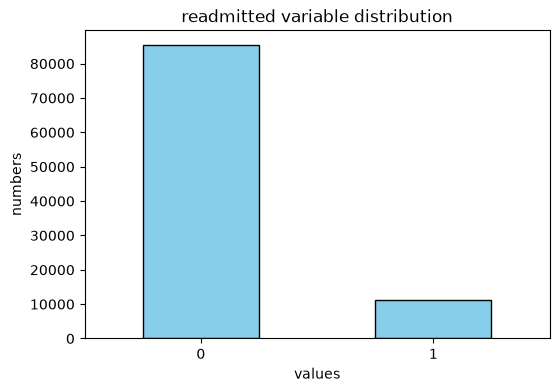

In [28]:
import matplotlib.pyplot as plt

counts = df['readmitted'].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('readmitted variable distribution')
plt.xlabel('values')
plt.ylabel('numbers')
plt.xticks(rotation=0)
plt.show()

#### Time in Hospital and Readmission


C:\Users\HOME\AppData\Local\Temp\ipykernel_9932\4190758192.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df.loc[(df['readmitted'] == 0),'time_in_hospital'] , color='b',shade=True,label='Not Readmitted')
C:\Users\HOME\AppData\Local\Temp\ipykernel_9932\4190758192.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df.loc[(df['readmitted'] == 1),'time_in_hospital'] , color='r',shade=True, label='Readmitted')


Text(0.5, 1.0, 'Time in Hospital VS. Readmission')

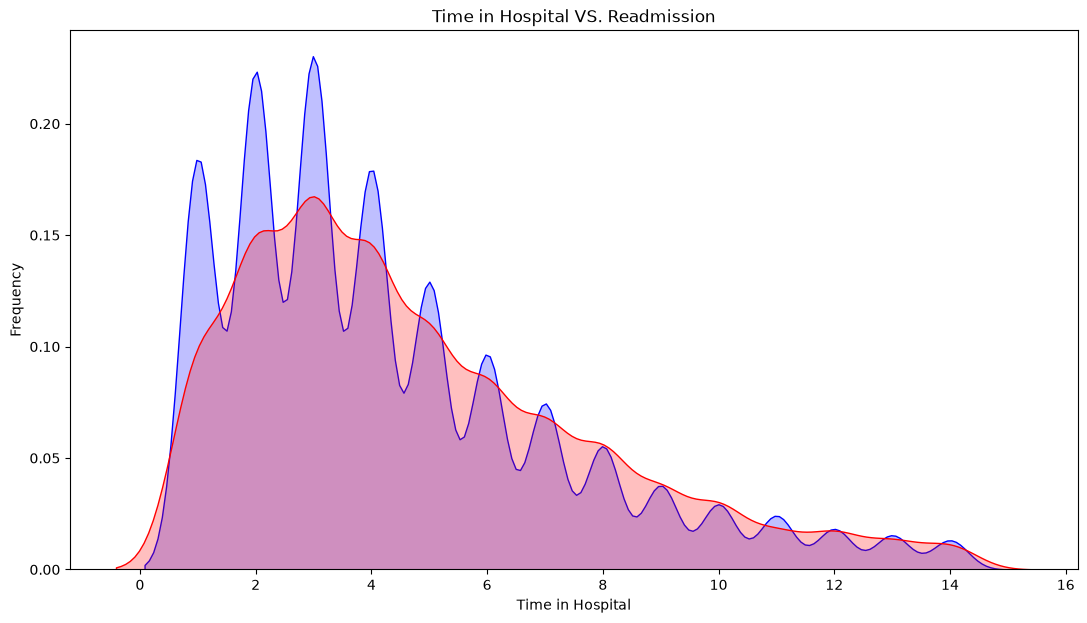

In [29]:
fig = plt.figure(figsize=(13,7),)
ax=sns.kdeplot(df.loc[(df['readmitted'] == 0),'time_in_hospital'] , color='b',shade=True,label='Not Readmitted')
ax=sns.kdeplot(df.loc[(df['readmitted'] == 1),'time_in_hospital'] , color='r',shade=True, label='Readmitted')
ax.set(xlabel='Time in Hospital', ylabel='Frequency')
plt.title('Time in Hospital VS. Readmission')

#### Age and Readmission

Text(0.5, 1.0, 'Age of Patient VS. Readmission')

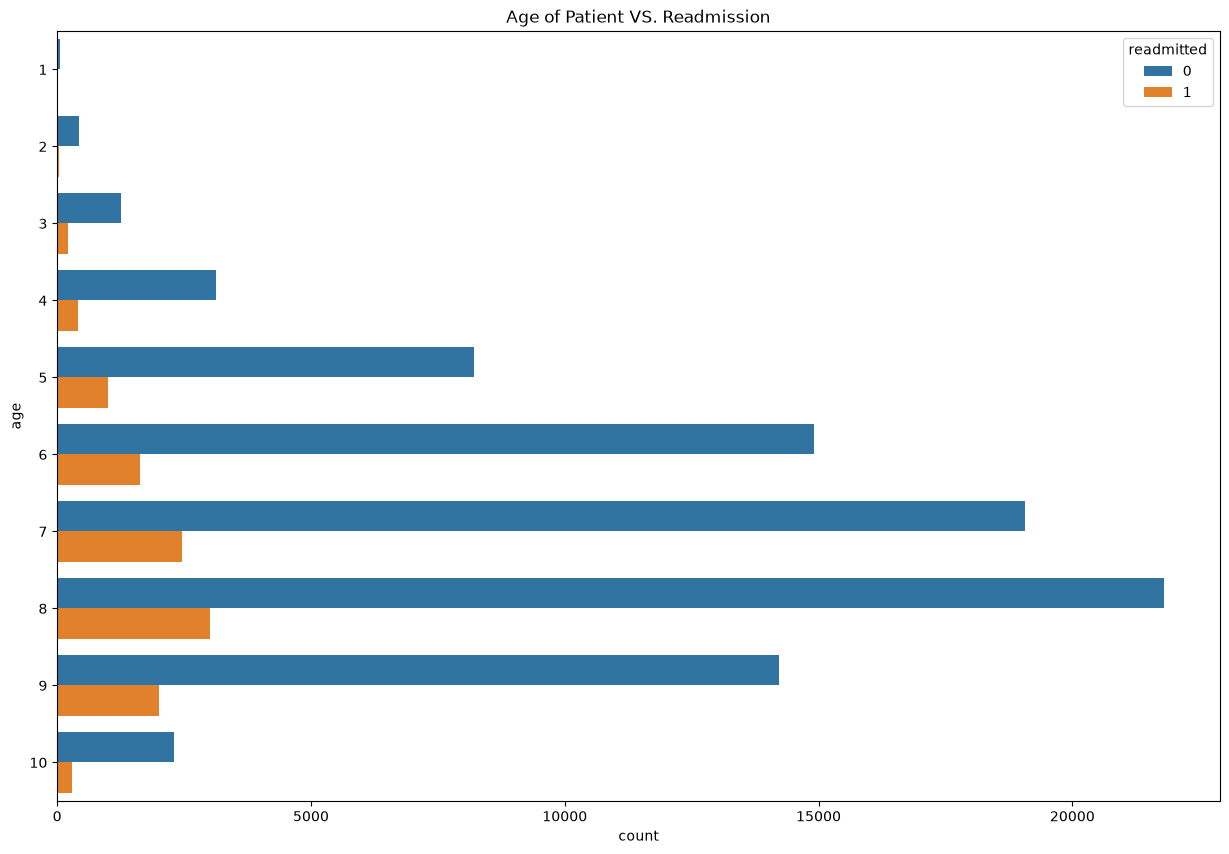

In [30]:
fig = plt.figure(figsize=(15,10))
sns.countplot(y= df['age'], hue = df['readmitted']).set_title('Age of Patient VS. Readmission')

#### Ethnicity of patient and Readmission

<Axes: xlabel='count', ylabel='race'>

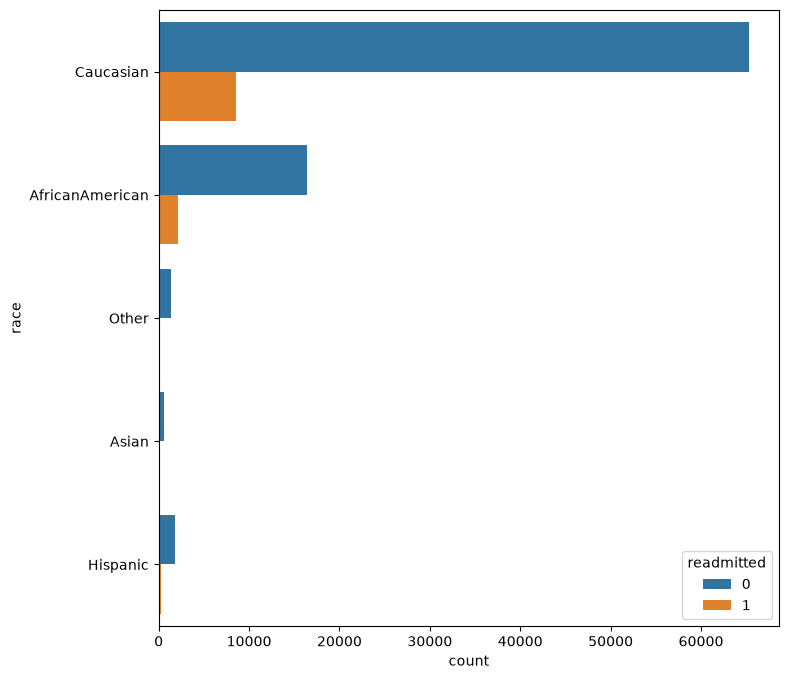

In [31]:
fig = plt.figure(figsize=(8,8))
sns.countplot(y = df['race'], hue = df['readmitted'])

#### Number of medication used and Readmission

Text(0.5, 1.0, 'Number of medication used VS. Readmission')

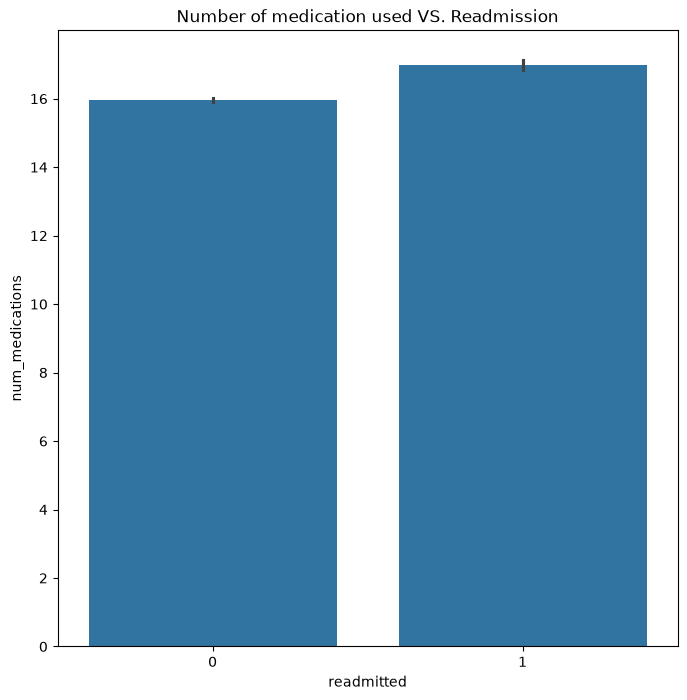

In [32]:
fig = plt.figure(figsize=(8,8))
sns.barplot(x = df['readmitted'], y = df['num_medications']).set_title("Number of medication used VS. Readmission")

#### Gender and Readmission
* Male = 1
* Female = 0

Text(0.5, 1.0, 'Gender of Patient VS. Readmission')

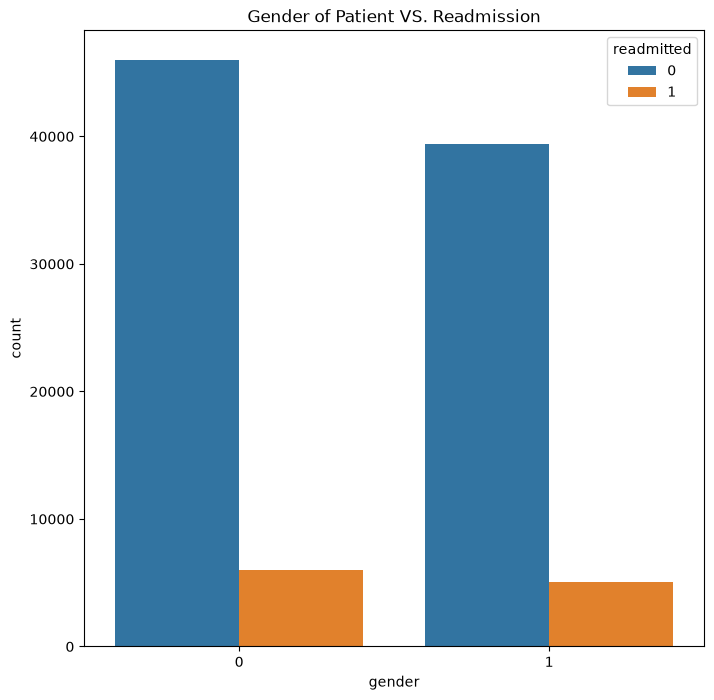

In [33]:
fig = plt.figure(figsize=(8,8))
sns.countplot(x = 'gender', hue = 'readmitted', data=df).set_title("Gender of Patient VS. Readmission")

#### Change of Medication and Readmission
* Change = 1
* No Change = 0

Text(0.5, 1.0, 'Change of Medication VS. Readmission')

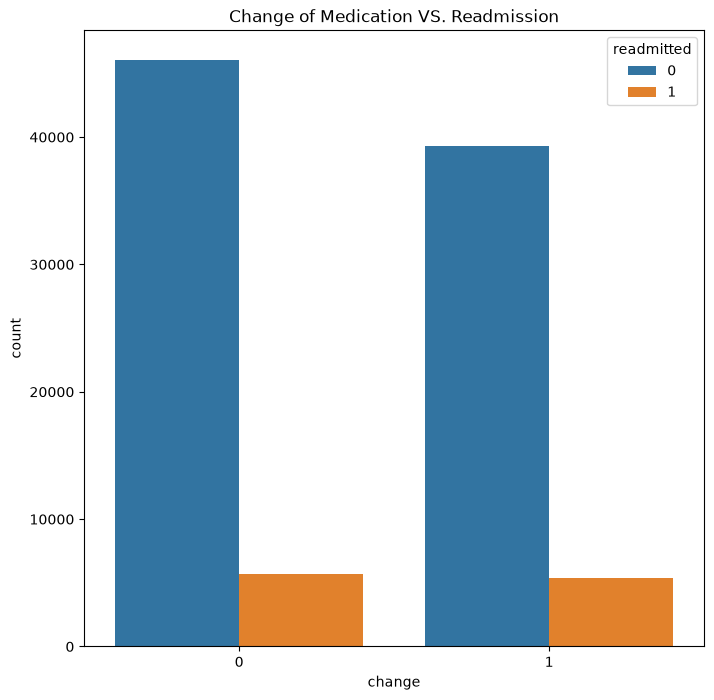

In [34]:
fig = plt.figure(figsize=(8,8))
sns.countplot(x = 'change', hue = 'readmitted', data = df).set_title('Change of Medication VS. Readmission')

#### Diabetes Medication prescribed and Readmission
* Diabetes Medication - medications Nominal Indicates if there was any diabetic medication prescribed.
* Values: “yes” : 1 “no” : 0

Text(0.5, 1.0, 'Diabetes Medication prescribed VS Readmission')

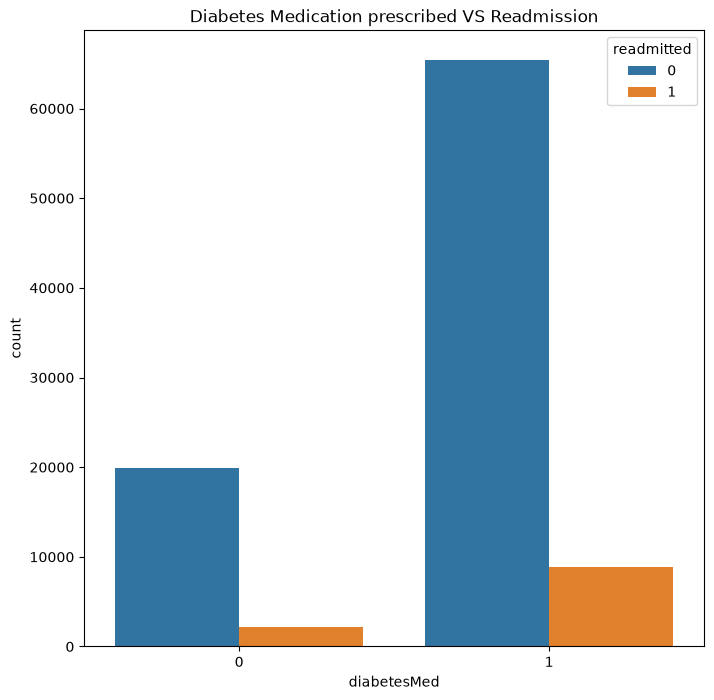

In [35]:
fig = plt.figure(figsize=(8,8))
sns.countplot(x = 'diabetesMed', hue = 'readmitted', data = df).set_title('Diabetes Medication prescribed VS Readmission')

#### Service Utilization and Readmission


Text(0.5, 1.0, 'Service Utilization VS. Readmission')

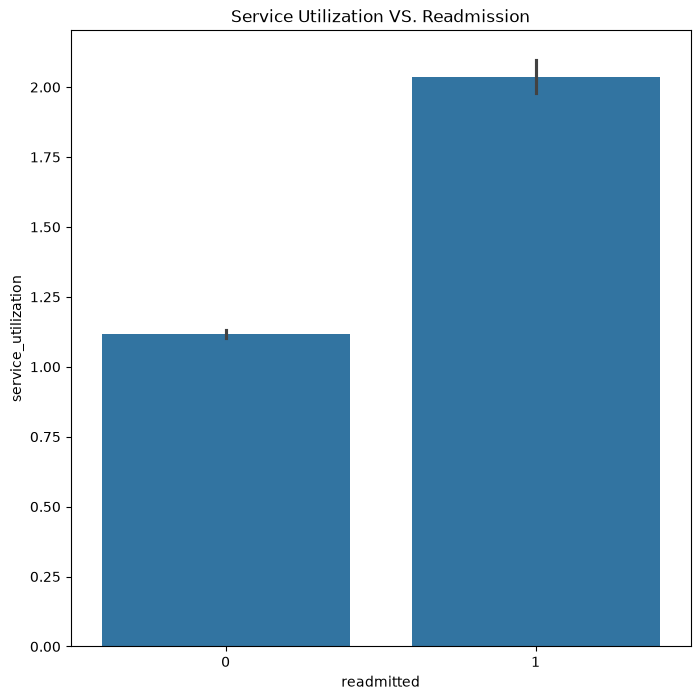

In [36]:
fig = plt.figure(figsize=(8,8))
sns.barplot( y = 'service_utilization', x = 'readmitted', data=df).set_title('Service Utilization VS. Readmission')

#### Glucose serum test result and Readmission
*Glucose Serum test* - A blood glucose test is used to find out if your blood sugar levels are in the healthy range. It is often used to help diagnose and monitor diabetes.

* '>200' : 1 = indicates diabetes
* '>300' : 1 = Indicates diabetes
* 'Norm' : 0 = Normal
* 'None' : -99 = test was not taken

Text(0.5, 1.0, 'Glucose test serum test result VS. Readmission')

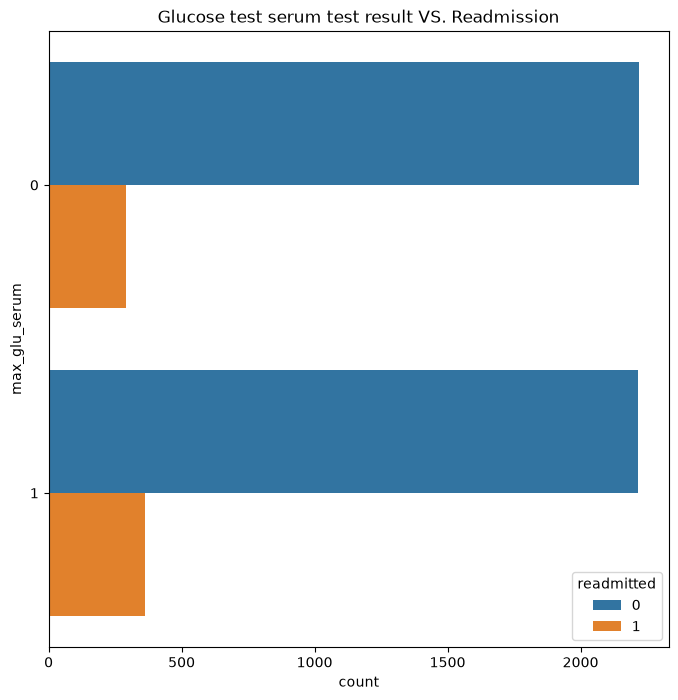

In [37]:
fig = plt.figure(figsize=(8,8))
sns.countplot(y = 'max_glu_serum', hue = 'readmitted', data=df).set_title('Glucose test serum test result VS. Readmission')

A1C result and Readmission
*A1C test* - The A1C test is a blood test that provides information about your average levels of blood glucose, also called blood sugar, over the past 3 months.
*  '>7'   :  1   
*  '>8'   :  1   
*    Norm :  0  = Normal 
*    None : -99 = Test was not taken

Text(0.5, 1.0, 'A1C test result VS. Readmission')

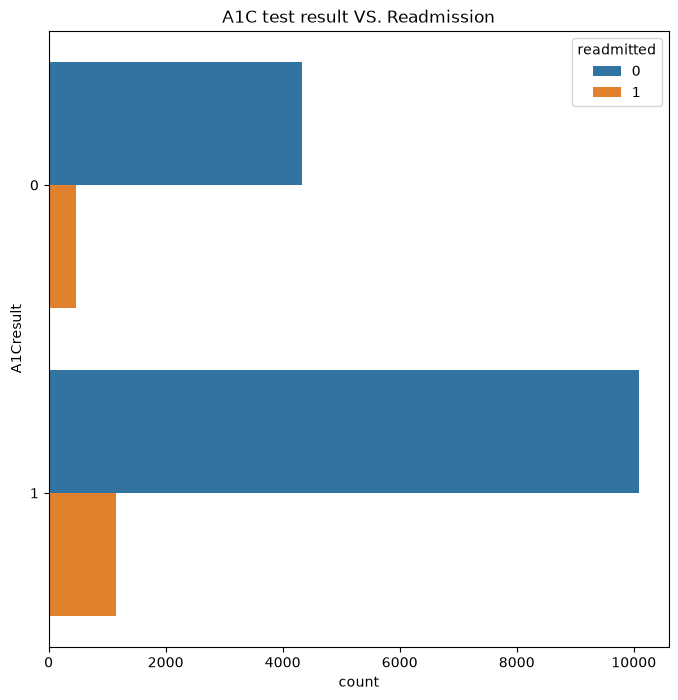

In [38]:
fig = plt.figure(figsize=(8,8))
sns.countplot(y= 'A1Cresult', hue = 'readmitted', data=df).set_title('A1C test result VS. Readmission')

#### Number of lab procedure and Readmission

C:\Users\HOME\AppData\Local\Temp\ipykernel_9932\1261402117.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df.loc[(df['readmitted'] == 0),'num_lab_procedures'] , color='b',shade=True,label='Not readmitted')
C:\Users\HOME\AppData\Local\Temp\ipykernel_9932\1261402117.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df.loc[(df['readmitted'] == 1),'num_lab_procedures'] , color='r',shade=True, label='readmitted')


Text(0.5, 1.0, 'Number of lab procedure VS. Readmission')

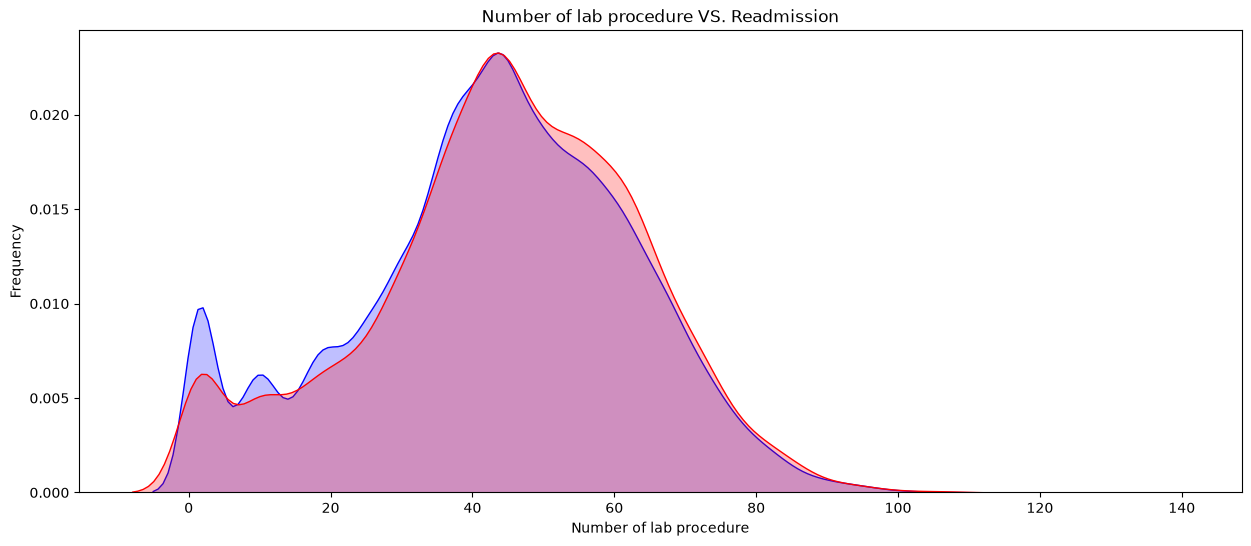

In [39]:
fig = plt.figure(figsize=(15,6),)
ax=sns.kdeplot(df.loc[(df['readmitted'] == 0),'num_lab_procedures'] , color='b',shade=True,label='Not readmitted')
ax=sns.kdeplot(df.loc[(df['readmitted'] == 1),'num_lab_procedures'] , color='r',shade=True, label='readmitted')
ax.set(xlabel='Number of lab procedure', ylabel='Frequency')
plt.title('Number of lab procedure VS. Readmission')

### Pre-Modeling Data Preprocessing
This code converts age as categorical variable to a continuous approximation by assuming mid-point of each age-category as the actual age value. This is done to avoid having to deal with age as a dummy variable in the models which makes interpretation very cumbersome. Also, since age category is not purely nominal but ordinal, we do not want to lose that information by treating it as a simple categorical variable

In [40]:
df['age'] = df['age'].astype('int64')
print(df.age.value_counts())
# convert age categories to mid-point values
age_dict = {1:5, 2:15, 3:25, 4:35, 5:45, 6:55, 7:65, 8:75, 9:85, 10:95}
df['age'] = df.age.map(age_dict)
print(df.age.value_counts())

age
8     24815
7     21521
6     16546
9     16223
5      9208
4      3538
10     2594
3      1471
2       466
1        64
Name: count, dtype: int64
age
75    24815
65    21521
55    16546
85    16223
45     9208
35     3538
95     2594
25     1471
15      466
5        64
Name: count, dtype: int64


In [41]:
# convert data type of nominal features in dataframe to 'object' type
i = ['encounter_id', 'patient_nbr', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',\
          'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', \
          'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose','miglitol', \
          'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', \
          'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', \
          'age', 'A1Cresult', 'max_glu_serum', 'level1_diag1', 'level1_diag2', 'level1_diag3', 'level2_diag1', 'level2_diag2', 'level2_diag3']

for col in i:
    df[col] = df[col].astype('object')

In [42]:
df.dtypes

encounter_id                object
patient_nbr                 object
race                           str
gender                      object
age                         object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                         str
diag_2                         str
diag_3                         str
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide           

* Number of medication used: Another possibly related factor could be the total number of medications used by the patient (which may indicate severity of their condition and/or the intensity of care). So we created another feature by counting the medications used during the encounter (keys variable in code below is continued from above):

In [43]:
df['nummed'] = 0

for col in keys:
    df['nummed'] = df['nummed'] + df[col]
df['nummed'].value_counts()

nummed
1    44589
0    22156
2    20901
3     7448
4     1290
5       57
6        5
Name: count, dtype: int64

In [44]:
# get list of only numeric features
num_col = list(set(list(df._get_numeric_data().columns))- {'readmitted'})
num_col

['num_procedures',
 'time_in_hospital',
 'number_diagnoses',
 'number_emergency',
 'num_medications',
 'num_lab_procedures',
 'numchange',
 'number_outpatient',
 'service_utilization',
 'number_inpatient']

In [45]:
# Removing skewnewss and kurtosis using log transformation if it is above a threshold value -  2

statdataframe = pd.DataFrame()
statdataframe['numeric_column'] = num_col
skew_before = []
skew_after = []

kurt_before = []
kurt_after = []

standard_deviation_before = []
standard_deviation_after = []

log_transform_needed = []

log_type = []

for i in num_col:
    skewval = df[i].skew()
    skew_before.append(skewval)
    
    kurtval = df[i].kurtosis()
    kurt_before.append(kurtval)
    
    sdval = df[i].std()
    standard_deviation_before.append(sdval)
    
    if (abs(skewval) >2) & (abs(kurtval) >2):
        log_transform_needed.append('Yes')
        
        if len(df[df[i] == 0])/len(df) <=0.02:
            log_type.append('log')
            skewvalnew = np.log(pd.DataFrame(df[train_data[i] > 0])[i]).skew()
            skew_after.append(skewvalnew)
            
            kurtvalnew = np.log(pd.DataFrame(df[train_data[i] > 0])[i]).kurtosis()
            kurt_after.append(kurtvalnew)
            
            sdvalnew = np.log(pd.DataFrame(df[train_data[i] > 0])[i]).std()
            standard_deviation_after.append(sdvalnew)
            
        else:
            log_type.append('log1p')
            skewvalnew = np.log1p(pd.DataFrame(df[df[i] >= 0])[i]).skew()
            skew_after.append(skewvalnew)
        
            kurtvalnew = np.log1p(pd.DataFrame(df[df[i] >= 0])[i]).kurtosis()
            kurt_after.append(kurtvalnew)
            
            sdvalnew = np.log1p(pd.DataFrame(df[df[i] >= 0])[i]).std()
            standard_deviation_after.append(sdvalnew)
            
    else:
        log_type.append('NA')
        log_transform_needed.append('No')
        
        skew_after.append(skewval)
        kurt_after.append(kurtval)
        standard_deviation_after.append(sdval)

statdataframe['skew_before'] = skew_before
statdataframe['kurtosis_before'] = kurt_before
statdataframe['standard_deviation_before'] = standard_deviation_before
statdataframe['log_transform_needed'] = log_transform_needed
statdataframe['log_type'] = log_type
statdataframe['skew_after'] = skew_after
statdataframe['kurtosis_after'] = kurt_after
statdataframe['standard_deviation_after'] = standard_deviation_after

In [46]:
statdataframe

,numeric_column,skew_before,kurtosis_before,standard_deviation_before,log_transform_needed,log_type,skew_after,kurtosis_after,standard_deviation_after
0,num_procedures,1.313236,0.856100,1.703183,No,NA,1.313236,0.856100,1.703183
1,time_in_hospital,1.127510,0.839050,2.982330,No,NA,1.127510,0.839050,2.982330
2,number_diagnoses,-0.807741,-0.372558,1.836659,No,NA,-0.807741,-0.372558,1.836659
3,number_emergency,22.695921,1165.140400,0.948089,Yes,log1p,3.614471,15.854105,0.318742
4,num_medications,1.339187,3.549325,8.072516,No,NA,1.339187,3.549325,8.072516
5,num_lab_procedures,-0.240626,-0.253275,19.656782,No,NA,-0.240626,-0.253275,19.656782
6,numchange,1.426548,1.451898,0.488614,No,NA,1.426548,1.451898,0.488614
7,number_outpatient,8.767489,146.244961,1.280061,Yes,log1p,2.708627,7.648535,0.432949
8,service_utilization,5.312374,67.194018,2.315789,Yes,log1p,1.097244,0.497241,0.665656
9,number_inpatient,3.566269,20.044813,1.269975,Yes,log1p,1.425127,1.319186,0.513389


In [47]:
# performing the log transformation for the columns determined to be needing it above.

for i in range(len(statdataframe)):
    if statdataframe['log_transform_needed'][i] == 'Yes':
        colname = str(statdataframe['numeric_column'][i])
        
        if statdataframe['log_type'][i] == 'log':
            df = df[df[colname] > 0]
            df[colname + "_log"] = np.log(df[colname])
            
        elif statdataframe['log_type'][i] == 'log1p':
            df = df[df[colname] >= 0]
            df[colname + "_log1p"] = np.log1p(df[colname])

In [48]:
df = df.drop(['number_outpatient', 'number_inpatient', 'number_emergency','service_utilization'], axis = 1)

In [49]:
df.shape

(96446, 54)

In [50]:
df['num_procedures'].value_counts()

num_procedures
0    44022
1    19740
2    12131
3     9018
6     4674
4     3971
5     2890
Name: count, dtype: int64

In [51]:
# get list of only numeric features
numerics = list(set(list(df._get_numeric_data().columns))- {'readmitted'})
numerics

['num_procedures',
 'number_emergency_log1p',
 'time_in_hospital',
 'number_diagnoses',
 'num_medications',
 'num_lab_procedures',
 'number_inpatient_log1p',
 'numchange',
 'service_utilization_log1p',
 'number_outpatient_log1p']

In [52]:
# show list of features that are categorical
df.encounter_id = df.encounter_id.astype('int64')
df.patient_nbr = df.patient_nbr.astype('int64')
df.diabetesMed = df.diabetesMed.astype('int64')
df.change = df.change.astype('int64')

# convert data type of nominal features in dataframe to 'object' type for aggregating
i = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', \
          'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose','miglitol', \
          'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', \
          'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
df[i] = df[i].astype('int64')

df.dtypes

encounter_id                   int64
patient_nbr                    int64
race                             str
gender                        object
age                           object
admission_type_id             object
discharge_disposition_id      object
admission_source_id           object
time_in_hospital               int64
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
diag_1                           str
diag_2                           str
diag_3                           str
number_diagnoses               int64
max_glu_serum                 object
A1Cresult                     object
metformin                      int64
repaglinide                    int64
nateglinide                    int64
chlorpropamide                 int64
glimepiride                    int64
acetohexamide                  int64
glipizide                      int64
glyburide                      int64
tolbutamide                    int64
p

In [55]:
# import sklearn.preprocessing as preprocessing

# encoder = preprocessing.OneHotEncoder(
#     handle_unknown='ignore',
#     sparse_output=False
# )

In [53]:
df['max_glu_serum'] = df['max_glu_serum'].fillna('Unknown')
df['A1Cresult'] = df['A1Cresult'].fillna('Unknown')

In [57]:
# cat_cols = ['max_glu_serum', 'A1Cresult']
# df[cat_cols] = df[cat_cols].astype(str)

# encoded = encoder.fit_transform(df[cat_cols])

# encoded_df = pd.DataFrame(
#     encoded,
#     columns=encoder.get_feature_names_out(cat_cols),
#     index=df.index
# )

# df = pd.concat([df, encoded_df], axis=1)

# df.head(10).T

In [58]:
# df = df.drop(['max_glu_serum', 'A1Cresult'], axis = 1)
# df.head(10).T

In [54]:
dfcopy = df.copy(deep = True)

In [55]:
df['readmitted'].value_counts()

readmitted
0    85380
1    11066
Name: count, dtype: int64

In [56]:
df['readmitted'] = df['readmitted'].apply(lambda x: 0 if x == 2 else x)

In [57]:
df['readmitted'].value_counts()

readmitted
0    85380
1    11066
Name: count, dtype: int64

In [58]:
df.info()

<class 'pandas.DataFrame'>
Index: 96446 entries, 1 to 101765
Data columns (total 54 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   encounter_id               96446 non-null  int64  
 1   patient_nbr                96446 non-null  int64  
 2   race                       96446 non-null  str    
 3   gender                     96446 non-null  object 
 4   age                        96446 non-null  object 
 5   admission_type_id          96446 non-null  object 
 6   discharge_disposition_id   96446 non-null  object 
 7   admission_source_id        96446 non-null  object 
 8   time_in_hospital           96446 non-null  int64  
 9   num_lab_procedures         96446 non-null  int64  
 10  num_procedures             96446 non-null  int64  
 11  num_medications            96446 non-null  int64  
 12  diag_1                     96446 non-null  str    
 13  diag_2                     96446 non-null  str    
 14  diag_

In [59]:
# drop individual diagnosis columns that have too granular disease information
# also drop level 2 categorization (which was not comparable with any reference)
# also drop level 1 secondary and tertiary diagnoses
df.drop(['diag_1', 'diag_2', 'diag_3', 'level2_diag1', 'level1_diag2', 'level2_diag2', 'level1_diag3',
         'level2_diag3'], axis=1, inplace=True)

In [60]:
df['age'].value_counts()

age
75    24815
65    21521
55    16546
85    16223
45     9208
35     3538
95     2594
25     1471
15      466
5        64
Name: count, dtype: int64

In [61]:
df.shape

(96446, 46)

In [62]:
interactionterms = [('num_medications','time_in_hospital'),
('num_medications','num_procedures'),
('time_in_hospital','num_lab_procedures'),
('num_medications','num_lab_procedures'),
('num_medications','number_diagnoses'),
('age','number_diagnoses'),
('change','num_medications'),
('number_diagnoses','time_in_hospital'),
('num_medications','numchange')]

In [63]:
for inter in interactionterms:
    name = inter[0] + '|' + inter[1]
    df[name] = df[inter[0]] * df[inter[1]]

In [64]:
df[['num_medications','time_in_hospital', 'num_medications|time_in_hospital']].head()

,num_medications,time_in_hospital,num_medications|time_in_hospital
1,18,3,54
2,13,2,26
3,16,2,32
4,8,1,8
5,16,3,48


In [65]:
df.shape

(96446, 55)

In [66]:
std_scale_features = ['num_lab_procedures',
 'number_inpatient_log1p',
 'service_utilization_log1p',
 'number_emergency_log1p',
 'num_medications',
 'numchange',
 'number_diagnoses',
 'number_outpatient_log1p']

In [67]:
# Feature Scaling
datf = pd.DataFrame()
datf['features'] = std_scale_features
datf['std_dev'] = datf['features'].apply(lambda x: df[x].std())
datf['mean'] = datf['features'].apply(lambda x: df[x].mean())

In [68]:
# dropping multiple encounters while keeping either first or last encounter of these patients
df2 = df.drop_duplicates(subset= ['patient_nbr'], keep = 'first')
df2.shape

(67580, 55)

In [69]:
# standardize function
def standardize(raw_data):
    return ((raw_data - np.mean(raw_data, axis = 0)) / np.std(raw_data, axis = 0))

In [70]:
df2[std_scale_features] = standardize(df2[std_scale_features])
import scipy as sp
df2 = df2[(np.abs(sp.stats.zscore(df2[std_scale_features])) < 3).all(axis=1)]

In [71]:
df2.shape

(60201, 55)

Min-max scaler for  'num_procedures', 'time_in_hospital'

In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
min_max_scaled_features = [ 'num_procedures','time_in_hospital']
df2[min_max_scaled_features] = scaler.fit_transform(df2[min_max_scaled_features])

In [73]:
df2['num_procedures'].value_counts()

num_procedures
0.000000    26565
0.166667    12181
0.333333     7776
0.500000     6102
1.000000     3003
0.666667     2549
0.833333     2025
Name: count, dtype: int64

In [74]:
df2['time_in_hospital'].value_counts()

time_in_hospital
0.153846    10847
0.076923    10644
0.000000     9206
0.230769     8165
0.307692     5808
0.384615     4294
0.461538     3272
0.538462     2353
0.615385     1596
0.692308     1213
0.769231      971
0.846154      738
0.923077      599
1.000000      495
Name: count, dtype: int64

In [75]:
df2.shape

(60201, 55)

In [76]:
df2.head().T

,1,2,3,4,5
encounter_id,149190,64410,500364,16680,35754
patient_nbr,55629189,86047875,82442376,42519267,82637451
race,Caucasian,AfricanAmerican,Caucasian,Caucasian,Caucasian
gender,0,0,1,1,1
age,15,25,35,45,55
admission_type_id,1,1,1,1,1
discharge_disposition_id,1,1,1,1,1
admission_source_id,7,7,7,7,1
time_in_hospital,0.153846,0.076923,0.076923,0.0,0.153846
num_lab_procedures,0.803605,-1.60206,0.051835,0.402661,-0.5997


In [77]:
from matplotlib.colors import ListedColormap
my_cmap = ListedColormap(sns.light_palette((250, 100, 50), input="husl", n_colors=50).as_hex())
table = df2.drop(['patient_nbr', 'encounter_id', 'race', 'max_glu_serum', 'A1Cresult'], axis=1).corr(method='pearson')
table.style.background_gradient(cmap=my_cmap, axis = 0)

d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,numchange,level1_diag1,nummed,number_emergency_log1p,number_outpatient_log1p,service_utilization_log1p,number_inpatient_log1p,num_medications|time_in_hospital,num_medications|num_procedures,time_in_hospital|num_lab_procedures,num_medications|num_lab_procedures,num_medications|number_diagnoses,age|number_diagnoses,change|num_medications,number_diagnoses|time_in_hospital,num_medications|numchange
gender,1.000000,-0.056886,0.007057,0.001467,-0.000429,-0.029725,0.003738,0.065520,-0.034298,0.001363,0.001541,-0.003067,-0.005833,0.004263,-0.001424,-0.003808,0.027638,0.031301,0.002129,0.013107,0.009157,0.006414,-0.002976,0.007556,0.006946,-0.002475,0.001375,0.005366,nan,nan,-0.003808,0.015098,0.017959,-0.002706,0.005645,-0.026200,0.025315,-0.018727,-0.010438,-0.013125,0.003609,-0.026277,0.044541,-0.015304,-0.012307,-0.026038,-0.035390,0.001011,-0.025261,-0.001328
age,-0.056886,1.000000,-0.005567,0.014845,0.044451,0.122449,0.023607,-0.037215,0.047692,0.218349,-0.066466,0.039562,0.015855,0.015092,0.032651,0.002375,0.047682,0.077155,0.010548,0.011995,-0.000722,0.010710,0.008848,-0.001915,0.006816,-0.080274,-0.002595,0.002337,nan,nan,-0.000236,-0.041214,-0.021875,0.044578,-0.069148,-0.007242,-0.010870,-0.012285,0.028967,0.031800,0.032129,0.086238,-0.023512,0.092544,0.041610,0.111282,0.741505,-0.010106,0.164098,-0.033658
admission_type_id,0.007057,-0.005567,1.000000,0.084535,-0.182776,-0.038677,-0.135762,0.121495,0.114494,-0.108632,0.012563,-0.012937,-0.009365,0.010898,-0.010053,-0.002489,0.011635,-0.000598,0.002776,0.011602,0.007356,0.006678,-0.003946,0.002629,0.012518,-0.051195,-0.006840,-0.002042,nan,nan,0.003522,-0.009140,-0.013906,-0.005803,-0.002409,0.088906,-0.017283,-0.008124,0.080740,0.069386,0.029281,0.012054,0.116180,-0.080702,-0.025282,0.034763,-0.083615,0.031487,-0.068863,0.014640
discharge_disposition_id,0.001467,0.014845,0.084535,1.000000,-0.006837,0.059139,0.007104,0.009572,-0.000659,-0.053573,-0.007187,-0.013110,-0.019935,0.027228,-0.030706,-0.000115,-0.017613,0.066888,-0.002938,-0.028053,-0.015370,0.009941,-0.003410,0.009702,0.009098,-0.100294,-0.014742,-0.000305,nan,nan,-0.000115,-0.052557,-0.055567,0.025426,-0.033261,-0.006993,-0.063117,-0.036615,-0.052474,-0.071175,-0.036718,0.036803,0.017806,0.043425,-0.002668,-0.026707,-0.028510,-0.044924,0.036159,-0.033604
admission_source_id,-0.000429,0.044451,-0.182776,-0.006837,1.000000,0.025904,0.190352,-0.186802,-0.103862,0.109233,-0.028736,0.007495,-0.013513,-0.001687,-0.023025,0.002798,0.006663,0.000419,0.000388,-0.014748,-0.014795,0.000315,0.002471,0.004847,0.002455,0.026651,-0.012064,0.001074,nan,nan,-0.005575,0.011170,0.001815,0.004782,0.041692,-0.128504,-0.010524,0.056936,-0.013924,0.020877,0.013967,-0.014032,-0.156209,0.090234,0.058798,-0.025532,0.108083,-0.029296,0.054842,0.016149
time_in_hospital,-0.029725,0.122449,-0.038677,0.059139,0.025904,1.000000,0.319868,0.151715,0.445968,0.223919,-0.014951,0.029857,0.007259,0.000188,0.007417,0.013852,0.013199,0.024433,0.004369,-0.004191,-0.001767,0.003828,-0.002557,0.005219,-0.006928,0.094768,-0.000627,0.001916,nan,nan,0.002542,0.093017,0.058575,0.053798,0.140159,0.016688,0.061732,-0.002506,-0.028401,0.008097,0.054838,0.864254,0.279547,0.857171,0.505171,0.460731,0.224531,0.232537,0.941652,0.232437
num_lab_procedures,0.003738,0.023607,-0.135762,0.007104,0.190352,0.319868,1.000000,0.018441,0.236236,0.139968,-0.051026,0.005011,-0.008484,-0.002496,-0.008942,0.005302,0.016700,0.002918,0.000511,-0.017431,-0.008732,-0.001450,-0.003697,0.005134,-0.001108,0.1005

In [78]:
j = ['gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'level1_diag1']
for col in j:
    df2[col] = df2[col].astype('int64')

In [79]:
# df_pd = pd.get_dummies(df2, columns=['race'])
df_pd = df2.copy(deep = True)

In [80]:
df_pd.info()

<class 'pandas.DataFrame'>
Index: 60201 entries, 1 to 101765
Data columns (total 55 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   encounter_id                         60201 non-null  int64  
 1   patient_nbr                          60201 non-null  int64  
 2   race                                 60201 non-null  str    
 3   gender                               60201 non-null  int64  
 4   age                                  60201 non-null  object 
 5   admission_type_id                    60201 non-null  int64  
 6   discharge_disposition_id             60201 non-null  int64  
 7   admission_source_id                  60201 non-null  int64  
 8   time_in_hospital                     60201 non-null  float64
 9   num_lab_procedures                   60201 non-null  float64
 10  num_procedures                       60201 non-null  float64
 11  num_medications                      60201 

In [81]:
num_cols = list(set(list(df._get_numeric_data().columns))- {'readmitted', 'change'})
num_cols

['glipizide-metformin',
 'num_medications|num_procedures',
 'pioglitazone',
 'chlorpropamide',
 'metformin-rosiglitazone',
 'num_procedures',
 'glimepiride',
 'number_emergency_log1p',
 'num_medications|numchange',
 'rosiglitazone',
 'glyburide-metformin',
 'change|num_medications',
 'num_medications|num_lab_procedures',
 'number_inpatient_log1p',
 'numchange',
 'metformin-pioglitazone',
 'diabetesMed',
 'service_utilization_log1p',
 'time_in_hospital|num_lab_procedures',
 'number_diagnoses|time_in_hospital',
 'num_medications|number_diagnoses',
 'nateglinide',
 'insulin',
 'acarbose',
 'num_medications',
 'patient_nbr',
 'metformin',
 'encounter_id',
 'miglitol',
 'troglitazone',
 'glyburide',
 'tolbutamide',
 'num_medications|time_in_hospital',
 'glimepiride-pioglitazone',
 'time_in_hospital',
 'number_diagnoses',
 'tolazamide',
 'acetohexamide',
 'num_lab_procedures',
 'repaglinide',
 'glipizide',
 'number_outpatient_log1p']

In [82]:
len(num_cols)

42

In [83]:
num_cols_2 = list(set(list(df_pd._get_numeric_data().columns))- {'readmitted', 'change'})
len(num_cols_2)

47

In [84]:
df_pd.shape

(60201, 55)

In [85]:
l = []
for feature in list(df_pd.columns):
    if '|' in feature:
        l.append(feature)
l

['num_medications|time_in_hospital',
 'num_medications|num_procedures',
 'time_in_hospital|num_lab_procedures',
 'num_medications|num_lab_procedures',
 'num_medications|number_diagnoses',
 'age|number_diagnoses',
 'change|num_medications',
 'number_diagnoses|time_in_hospital',
 'num_medications|numchange']

In [86]:
df_pd.head(10)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_inpatient_log1p,num_medications|time_in_hospital,num_medications|num_procedures,time_in_hospital|num_lab_procedures,num_medications|num_lab_procedures,num_medications|number_diagnoses,age|number_diagnoses,change|num_medications,number_diagnoses|time_in_hospital,num_medications|numchange
1,149190,55629189,Caucasian,0,15,1,1,7,0.153846,0.803605,...,-0.349835,54,0,177,1062,162,135,18,27,18
2,64410,86047875,AfricanAmerican,0,25,1,1,7,0.076923,-1.602060,...,1.947984,26,65,22,143,78,150,0,12,0
3,500364,82442376,Caucasian,1,35,1,1,7,0.076923,0.051835,...,-0.349835,32,16,88,704,112,245,16,14,16
4,16680,42519267,Caucasian,1,45,1,1,7,0.000000,0.402661,...,-0.349835,8,0,51,408,40,225,8,5,0
5,35754,82637451,Caucasian,1,55,1,1,1,0.153846,-0.599700,...,-0.349835,48,96,93,496,144,495,0,27,0
6,55842,84259809,Caucasian,1,65,3,1,1,0.230769,1.354904,...,-0.349835,84,21,280,1470,147,455,21,28,0
7,63768,114882984,Caucasian,1,75,1,1,7,0.307692,1.505258,...,-0.349835,60,0,365,876,96,600,0,40,0
8,12522,48330783,Caucasian,0,85,1,1,4,0.923077,1.254668,...,-0.349835,364,56,884,1904,224,680,28,104,0
9,15738,63555939,Caucasian,0,95,3,2,4,0.846154,-0.499463,...,-0.349835,216,54,396,594,144,760,18,96,0
10,28236,89869032,AfricanAmerican,0,45,1,1,7,0.615385,0.202189,...,-0.349835,153,34,423,799,153,405,0,81,0


In [87]:
df_pd.shape

(60201, 55)

In [88]:
df_pd.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'numchange', 'level1_diag1', 'nummed', 'number_emergency_log1p',
       'number_outpatient_log1p', 'service_utilization_log1p',
       'number_inpatient_log1p', 'num_medications|time_in_hospital',
       'num_medications|num_procedures', 'time_in_hospital|num_lab_proc

## Modeling

In [89]:
feature_set = ['encounter_id', 'patient_nbr', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'numchange', 'level1_diag1', 'nummed', 'number_emergency_log1p',
       'service_utilization_log1p', 'number_outpatient_log1p',
       'number_inpatient_log1p', 'max_glu_serum_0', 'max_glu_serum_1',
       'max_glu_serum_Unknown', 'A1Cresult_0', 'A1Cresult_1',
       'A1Cresult_Unknown', 'num_medications|time_in_hospital',
       'num_medications|num_procedures', 'time_in_hospital|num_lab_procedures',
       'num_medications|num_lab_procedures',
       'num_medications|number_diagnoses', 'age|number_diagnoses',
       'change|num_medications', 'number_diagnoses|time_in_hospital',
       'num_medications|numchange', 'race_AfricanAmerican', 'race_Asian',
       'race_Caucasian', 'race_Hispanic', 'race_Other']

len(feature_set)

63

In [90]:
for col_name in ['age', 'nummed', 'age|number_diagnoses']:
    df_pd[col_name] = df_pd[col_name].astype('int64')

## numeric handle
1. 'num_medications|time_in_hospital'

2. 'num_medications|num_procedures'

3. 'time_in_hospital|num_lab_procedures'

4. 'num_medications|num_lab_procedures'

5. 'num_medications|number_diagnoses'

6. 'age|number_diagnoses'

7. 'change|num_medications'

8. 'number_diagnoses|time_in_hospital'

9. 'num_medications|numchange'

10. 'nummed'

11. 'age'

In [91]:
for col in feature_set:
    if col in df_pd.columns:
        col_type = df_pd[col].dtype
        print(f"Cột: {col:<35} | Kiểu dữ liệu: {col_type}")
    else:
        print(f" Cột '{col}' không có trong DataFrame!")

Cột: encounter_id                        | Kiểu dữ liệu: int64
Cột: patient_nbr                         | Kiểu dữ liệu: int64
Cột: gender                              | Kiểu dữ liệu: int64
Cột: age                                 | Kiểu dữ liệu: int64
Cột: admission_type_id                   | Kiểu dữ liệu: int64
Cột: discharge_disposition_id            | Kiểu dữ liệu: int64
Cột: admission_source_id                 | Kiểu dữ liệu: int64
Cột: time_in_hospital                    | Kiểu dữ liệu: float64
Cột: num_lab_procedures                  | Kiểu dữ liệu: float64
Cột: num_procedures                      | Kiểu dữ liệu: float64
Cột: num_medications                     | Kiểu dữ liệu: float64
Cột: number_diagnoses                    | Kiểu dữ liệu: float64
Cột: metformin                           | Kiểu dữ liệu: int64
Cột: repaglinide                         | Kiểu dữ liệu: int64
Cột: nateglinide                         | Kiểu dữ liệu: int64
Cột: chlorpropamide                      | Ki

In [92]:
df_pd['num_medications|time_in_hospital'].value_counts()

num_medications|time_in_hospital
24     1635
36     1614
60     1482
18     1420
30     1407
       ... 
507       5
400       5
111       4
546       4
74        4
Name: count, Length: 259, dtype: int64

In [93]:
# Removing skewnewss and kurtosis using log transformation if it is above a threshold value -  2

statdataframe = pd.DataFrame()
num_cols_3 = ['num_medications|time_in_hospital',
 'num_medications|num_procedures',
 'time_in_hospital|num_lab_procedures',
 'num_medications|num_lab_procedures',
 'num_medications|number_diagnoses',
 'age|number_diagnoses',
 'change|num_medications',
 'number_diagnoses|time_in_hospital',
 'num_medications|numchange', 'nummed']


statdataframe['numeric_column'] = num_cols_3
skew_before = []
skew_after = []

kurt_before = []
kurt_after = []

standard_deviation_before = []
standard_deviation_after = []

log_transform_needed = []

log_type = []

for i in num_cols_3:
    skewval = df_pd[i].skew()
    skew_before.append(skewval)
    
    kurtval = df_pd[i].kurtosis()
    kurt_before.append(kurtval)
    
    sdval = df_pd[i].std()
    standard_deviation_before.append(sdval)
    
    if (abs(skewval) >2) & (abs(kurtval) >2):
        log_transform_needed.append('Yes')
        
        if len(df_pd[df_pd[i] == 0])/len(df_pd) <=0.02:
            log_type.append('log')
            skewvalnew = np.log(df_pd.loc[df_pd[i] > 0, i]).skew()
            skew_after.append(skewvalnew)
            
            kurtvalnew = np.log(df_pd.loc[df_pd[i] > 0, i]).kurtosis()
            kurt_after.append(kurtvalnew)
            
            sdvalnew = np.log(df_pd.loc[df_pd[i] > 0, i]).std()
            standard_deviation_after.append(sdvalnew)
            
        else:
            log_type.append('log1p')
            skewvalnew = np.log1p(pd.DataFrame(df_pd[df_pd[i] >= 0])[i]).skew()
            skew_after.append(skewvalnew)
        
            kurtvalnew = np.log1p(pd.DataFrame(df_pd[df_pd[i] >= 0])[i]).kurtosis()
            kurt_after.append(kurtvalnew)
            
            sdvalnew = np.log1p(pd.DataFrame(df_pd[df_pd[i] >= 0])[i]).std()
            standard_deviation_after.append(sdvalnew)
            
    else:
        log_type.append('NA')
        log_transform_needed.append('No')
        
        skew_after.append(skewval)
        kurt_after.append(kurtval)
        standard_deviation_after.append(sdval)

statdataframe['skew_before'] = skew_before
statdataframe['kurtosis_before'] = kurt_before
statdataframe['standard_deviation_before'] = standard_deviation_before
statdataframe['log_transform_needed'] = log_transform_needed
statdataframe['log_type'] = log_type
statdataframe['skew_after'] = skew_after
statdataframe['kurtosis_after'] = kurt_after
statdataframe['standard_deviation_after'] = standard_deviation_after

In [94]:
statdataframe

,numeric_column,skew_before,kurtosis_before,standard_deviation_before,log_transform_needed,log_type,skew_after,kurtosis_after,standard_deviation_after
0,num_medications|time_in_hospital,2.144010,5.615669,76.190180,Yes,log,-0.265202,-0.215751,1.056203
1,num_medications|num_procedures,2.263515,6.083725,37.875927,Yes,log1p,0.081629,-1.636861,1.846345
2,time_in_hospital|num_lab_procedures,1.753649,3.629341,190.516045,No,NA,1.753649,3.629341,190.516045
3,num_medications|num_lab_procedures,1.342487,2.520382,513.040922,No,NA,1.342487,2.520382,513.040922
4,num_medications|number_diagnoses,0.869854,0.557622,66.435445,No,NA,0.869854,0.557622,66.435445
5,age|number_diagnoses,-0.103980,-0.832133,182.293194,No,NA,-0.103980,-0.832133,182.293194
6,change|num_medications,1.031708,0.001710,9.703927,No,NA,1.031708,0.001710,9.703927
7,number_diagnoses|time_in_hospital,1.369085,1.679824,25.121639,No,NA,1.369085,1.679824,25.121639
8,num_medications|numchange,2.000346,3.064234,8.247562,Yes,log1p,1.400575,0.096099,1.208121
9,nummed,0.670488,0.197541,0.931206,No,NA,0.670488,0.197541,0.931206


In [95]:
# performing the log transformation for the columns determined to be needing it above.

for i in range(len(statdataframe)):
    if statdataframe['log_transform_needed'][i] == 'Yes':
        colname = str(statdataframe['numeric_column'][i])
        
        if statdataframe['log_type'][i] == 'log':
            df_pd = df_pd[df_pd[colname] > 0]
            df_pd[colname + "_log"] = np.log(df_pd[colname])
            
        elif statdataframe['log_type'][i] == 'log1p':
            df_pd = df_pd[df_pd[colname] >= 0]
            df_pd[colname + "_log1p"] = np.log1p(df_pd[colname])

In [96]:
df_pd = df_pd.drop(['num_medications|numchange', 'num_medications|num_procedures', 'num_medications|time_in_hospital'], axis = 1)

In [97]:
std_scale_features_2 = ['num_medications|time_in_hospital_log', 
                        'num_medications|num_procedures_log1p', 
                        'time_in_hospital|num_lab_procedures',
                        'num_medications|num_lab_procedures',
                        'num_medications|number_diagnoses',
                        'age|number_diagnoses', 'change|num_medications', 
                        'number_diagnoses|time_in_hospital',
                        'num_medications|numchange_log1p', 'nummed']

In [98]:
df_pd.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'numchange', 'level1_diag1', 'nummed', 'number_emergency_log1p',
       'number_outpatient_log1p', 'service_utilization_log1p',
       'number_inpatient_log1p', 'time_in_hospital|num_lab_procedures',
       'num_medications|num_lab_procedures',
       'num_medications

In [104]:
# # Feature Scaling
# datf = pd.DataFrame()
# datf['features'] = std_scale_features_2
# datf['std_dev'] = datf['features'].apply(lambda x: df_pd[x].std())
# datf['mean'] = datf['features'].apply(lambda x: df_pd[x].mean())

In [99]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
df_pd[std_scale_features_2] = std_scaler.fit_transform(df_pd[std_scale_features_2])

In [100]:
import scipy as sp
df_pd = df_pd[(np.abs(sp.stats.zscore(df_pd[std_scale_features_2])) < 3).all(axis=1)]

In [101]:
df_pd.shape

(56653, 55)

In [102]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()
df_pd['age'] = min_max_scaler.fit_transform(df_pd[['age']])

In [103]:
df_pd.head(10)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_inpatient_log1p,time_in_hospital|num_lab_procedures,num_medications|num_lab_procedures,num_medications|number_diagnoses,age|number_diagnoses,change|num_medications,number_diagnoses|time_in_hospital,num_medications|time_in_hospital_log,num_medications|num_procedures_log1p,num_medications|numchange_log1p
1,149190,55629189,Caucasian,0,0.111111,1,1,7,0.153846,0.803605,...,-0.349835,-0.099449,0.759149,0.733570,-1.923869,1.094790,-0.190439,0.189119,-1.061131,1.903227
2,64410,86047875,AfricanAmerican,0,0.222222,1,1,7,0.076923,-1.602060,...,1.947984,-0.913035,-1.032146,-0.530826,-1.841584,-0.760144,-0.787539,-0.502882,1.208050,-0.533998
3,500364,82442376,Caucasian,1,0.333333,1,1,7,0.076923,0.051835,...,-0.349835,-0.566605,0.061343,-0.019047,-1.320441,0.888686,-0.707926,-0.306290,0.473381,1.811161
4,16680,42519267,Caucasian,1,0.444444,1,1,7,0.000000,0.402661,...,-0.349835,-0.760816,-0.515613,-1.102814,-1.430155,0.064271,-1.066186,-1.618828,-1.061131,-0.533998
5,35754,82637451,Caucasian,1,0.555556,1,1,1,0.153846,-0.599700,...,-0.349835,-0.540360,-0.344086,0.462628,0.050988,-0.760144,-0.190439,0.077602,1.416602,-0.533998
6,55842,84259809,Caucasian,1,0.666667,3,1,1,0.230769,1.354904,...,-0.349835,0.441193,1.554414,0.507785,-0.168441,1.403946,-0.150633,0.607444,0.613025,-0.533998
7,63768,114882984,Caucasian,1,0.777778,1,1,7,0.307692,1.505258,...,-0.349835,0.887353,0.396602,-0.259884,0.626988,-0.760144,0.327047,0.288874,-1.061131,-0.533998
9,15738,63555939,Caucasian,0,1.000000,3,2,4,0.846154,-0.499463,...,-0.349835,1.050070,-0.153066,0.462628,1.504702,1.094790,2.556220,1.501656,1.109302,-0.533998
10,28236,89869032,AfricanAmerican,0,0.444444,1,1,7,0.615385,0.202189,...,-0.349835,1.191792,0.246515,0.598099,-0.442727,-0.760144,1.959120,1.175163,0.864500,-0.533998
11,36900,77391171,AfricanAmerican,1,0.666667,1,1,4,0.461538,0.953959,...,-0.349835,1.249530,0.018461,-0.545878,-0.168441,0.373427,0.685307,0.525062,-1.061131,1.522855


In [104]:
cat_df_pd = df_pd.copy(deep = True)

In [105]:
df_pd = pd.get_dummies(df_pd, columns=['race'])

In [106]:
df_pd['max_glu_serum'].value_counts()

max_glu_serum
Unknown    53996
0           1393
1           1264
Name: count, dtype: int64

In [107]:
# one-hot encoding for categorical id features
from sklearn.preprocessing import OneHotEncoder

cat_id_cols = ['admission_type_id', 'discharge_disposition_id', 
               'admission_source_id', 'level1_diag1', 'max_glu_serum', 'A1Cresult']
cat_id_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
df_pd[cat_id_cols] = df_pd[cat_id_cols].astype(str)

encoded = cat_id_encoder.fit_transform(df_pd[cat_id_cols])
encoded_cat_id_df = pd.DataFrame(
    encoded,
    columns=cat_id_encoder.get_feature_names_out(cat_id_cols),
    index=df_pd.index
)

df_pd = pd.concat([df_pd, encoded_cat_id_df], axis=1)

df_pd.head(10).T

,1,2,3,4,5,6,7,9,10,11
encounter_id,149190,64410,500364,16680,35754,55842,63768,15738,28236,36900
patient_nbr,55629189,86047875,82442376,42519267,82637451,84259809,114882984,63555939,89869032,77391171
gender,0,0,1,1,1,1,1,0,0,1
age,0.111111,0.222222,0.333333,0.444444,0.555556,0.666667,0.777778,1.0,0.444444,0.666667
admission_type_id,1,1,1,1,1,3,1,3,1,1
...,...,...,...,...,...,...,...,...,...,...
max_glu_serum_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max_glu_serum_Unknown,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
A1Cresult_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1Cresult_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
df_pd = df_pd.drop(columns=cat_id_cols)

In [109]:
df_pd.head(10).T

,1,2,3,4,5,6,7,9,10,11
encounter_id,149190,64410,500364,16680,35754,55842,63768,15738,28236,36900
patient_nbr,55629189,86047875,82442376,42519267,82637451,84259809,114882984,63555939,89869032,77391171
gender,0,0,1,1,1,1,1,0,0,1
age,0.111111,0.222222,0.333333,0.444444,0.555556,0.666667,0.777778,1.0,0.444444,0.666667
time_in_hospital,0.153846,0.076923,0.076923,0.0,0.153846,0.230769,0.307692,0.846154,0.615385,0.461538
...,...,...,...,...,...,...,...,...,...,...
max_glu_serum_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max_glu_serum_Unknown,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
A1Cresult_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1Cresult_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Train Test Split

In [110]:
model_data = df_pd.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore').copy(deep=True)

bool_cols = [c for c in model_data.columns if model_data[c].dtype == 'bool']
model_data[bool_cols] = model_data[bool_cols].astype(int)

X = model_data.drop(columns=['readmitted'])
y = model_data['readmitted']

In [111]:
cat_data = cat_df_pd.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore').copy(deep=True)
cat_for_cat_list = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 
                    'level1_diag1', 'max_glu_serum', 'A1Cresult', 'race']

cat_data[cat_for_cat_list] = cat_data[cat_for_cat_list].astype('category')

X_cat = cat_data.drop(columns=['readmitted'])
y_cat = cat_data['readmitted']

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

Tập dữ liệu resampling 70% dữ liệu lớp positive

In [113]:
X_train_cat_70, X_test_cat_70, y_train_cat_70, y_test_cat_70 = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

In [121]:
cat_cols_index = np.where(X_train_cat_70.dtypes == "category")[0].tolist()
print("Categorical column indices:", cat_cols_index)

Categorical column indices: [0, 3, 4, 5, 11, 12, 37]


In [124]:
for col in X_train_cat_70.select_dtypes(include=["category", "object"]).columns:
    print(col, X_train_cat_70[col].unique())

race ['Caucasian', 'AfricanAmerican', 'Hispanic', 'Other', 'Asian']
Categories (5, str): ['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other']
admission_type_id [1, 3, 5, 4]
Categories (4, int64): [1, 3, 4, 5]
discharge_disposition_id [1, 18, 2, 7, 10, 28, 20, 19, 27]
Categories (9, int64): [1, 2, 7, 10, ..., 19, 20, 27, 28]
admission_source_id [7, 1, 9, 4, 11, 8]
Categories (6, int64): [1, 4, 7, 8, 9, 11]
max_glu_serum ['Unknown', 1, 0]
Categories (3, object): [0, 1, 'Unknown']
A1Cresult ['Unknown', 1, 0]
Categories (3, object): [0, 1, 'Unknown']
level1_diag1 [4, 1, 0, 8, 7, 2, 6, 3, 5]
Categories (9, int64): [0, 1, 2, 3, ..., 5, 6, 7, 8]


In [125]:
for col in X_train_cat_70.select_dtypes(include=["category", "object"]).columns:
    X_train_cat_70[col] = X_train_cat_70[col].astype(str)

In [126]:
from imblearn.over_sampling import SMOTENC
smote = SMOTENC(random_state=42, sampling_strategy=0.7, categorical_features=cat_cols_index)
X_resampled, y_resampled = smote.fit_resample(X_train_cat_70, y_train_cat_70)

In [127]:
y_resampled.value_counts()

readmitted
0    41496
1    29047
Name: count, dtype: int64

In [128]:
for idx in cat_cols_index:
    col_name = X_resampled.columns[idx]
    X_resampled[col_name] = X_resampled[col_name].astype("category")

### Logistic Regression - baseline model

In [113]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight='balanced', 
        max_iter=2000,
        solver='lbfgs', 
        random_state=42
    )
)

In [114]:
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
y_pros = cross_val_predict(log_reg_pipeline, X_train, y_train, cv=cv, method='predict_proba')

y_scores = y_pros[:, 1]

log_reg_ap_score = average_precision_score(y_train, y_scores)
print(f"--- PR-AUC Score: {log_reg_ap_score:.4f} ---")

--- PR-AUC Score: 0.1328 ---


### XGBoost

In [115]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score

# 1. Tính tỉ lệ phạt trọng số (0 / 1)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Khởi tạo XGBoost có phạt trọng số nhãn lệch
xgb_classifier_default = XGBClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

# 3. Chia Fold và lấy xác suất
cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
y_pros = cross_val_predict(xgb_classifier_default, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)

# 4. Trích xuất xác suất nhãn 1 & Tính điểm PR-AUC
y_scores = y_pros[:, 1]
default_xgboost_ap_score = average_precision_score(y_train, y_scores)

print(f"--- XGBoost default PR-AUC Score: {default_xgboost_ap_score:.4f} ---")

--- XGBoost default PR-AUC Score: 0.1140 ---


In [116]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score

# Tắt bớt log không cần thiết của Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Tính tỷ lệ nhãn làm mốc gợi ý cho scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Định nghĩa hàm mục tiêu (Objective function)
def objective(trial):
    # Khai báo không gian tham số cần tối ưu
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 7),  # Giới hạn cây nông để chống overfit
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),   # L1 regularization
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # L2 regularization
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', ratio * 0.5, ratio * 1.5),
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    
    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
    
    model = XGBClassifier(**params)
    
    # Dự đoán xác suất qua CV
    y_probas = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)
    y_scores = y_probas[:, 1]
    
    # Mẫu số chung đánh giá: PR-AUC
    pr_auc = average_precision_score(y_train, y_scores)
    return pr_auc

# 3. Khởi tạo Study và chạy thử nghiệm
study = optuna.create_study(direction='maximize') # Mục tiêu: TỐI ĐA HÓA PR-AUC
study.optimize(objective, n_trials=50, show_progress_bar=True) # Chạy 50 lượt thử nghiệm

# 4. In kết quả tốt nhất
print("\n--- KẾT QUẢ TỐI ƯU BẰNG OPTUNA ---")
print(f"PR-AUC cao nhất đạt được: {study.best_value:.4f}")
print("Bộ tham số tối ưu (Best Parameters):")
for key, value in study.best_params.items():
    print(f"  '{key}': {value}")

d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 41. Best value: 0.1389: 100%|██████████| 50/50 [01:57<00:00,  2.36s/it]  


--- KẾT QUẢ TỐI ƯU BẰNG OPTUNA ---
PR-AUC cao nhất đạt được: 0.1389
Bộ tham số tối ưu (Best Parameters):
  'n_estimators': 200
  'max_depth': 3
  'learning_rate': 0.03270996351399617
  'subsample': 0.6717991736913069
  'colsample_bytree': 0.6255721712003399
  'min_child_weight': 3
  'gamma': 4.282505696879897
  'reg_alpha': 0.01955237068983772
  'reg_lambda': 0.00974232334007679
  'scale_pos_weight': 6.346157419237193


In [117]:
from xgboost import XGBClassifier

best_params = study.best_params

best_params['random_seed'] = 42
best_params['verbose'] = 0

xgboost_tunning_model = XGBClassifier(**best_params)

In [118]:
import joblib
joblib.dump(log_reg_pipeline, 'log_base_model.pkl')
joblib.dump(xgboost_tunning_model, 'xgboost_tunning.pkl')

['xgboost_tunning.pkl']

### CatBoost

In [136]:
import copy
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score

CatBoostClassifier.__sklearn_clone__ = lambda self: copy.deepcopy(self)
# ---------------------------------------------------

cat_cols = X_train_cat.select_dtypes(include=['object', 'category']).columns.tolist()

cat_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    iterations=500,
    learning_rate=0.03,
    depth=4,
    cat_features=cat_cols if len(cat_cols) > 0 else None,
    random_seed=42,
    verbose=0
)

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
y_probas = cross_val_predict(cat_model, X_train_cat, y_train_cat, cv=cv, method='predict_proba')

y_scores = y_probas[:, 1]
default_cat_ap_score = average_precision_score(y_train_cat, y_scores)

print(f"--- CatBoost default PR-AUC Score: {default_cat_ap_score:.4f} ---")

--- CatBoost default PR-AUC Score: 0.1371 ---


In [137]:
import copy
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

CatBoostClassifier.__sklearn_clone__ = lambda self: copy.deepcopy(self)

cat_cols = X_train_cat.select_dtypes(
    include=['category', 'object']
).columns.tolist()


def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600, step=100),
        'depth': trial.suggest_int('depth', 3, 7),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.2, log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1e-3, 10.0, log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength', 1e-3, 10.0, log=True
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature', 0.0, 1.0
        ),
        'auto_class_weights': trial.suggest_categorical(
            'auto_class_weights', ['Balanced', 'SqrtBalanced']
        ),
        'cat_features': cat_cols,
        'random_seed': 42,
        'verbose': 0,
    }

    cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
    model = CatBoostClassifier(**params)

    y_probas = cross_val_predict(
        model, X_train_cat, y_train_cat, cv=cv, method='predict_proba'
    )
    y_scores = y_probas[:, 1]

    return average_precision_score(y_train_cat, y_scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

Best trial: 47. Best value: 0.140128: 100%|██████████| 50/50 [3:18:54<00:00, 238.69s/it]  


In [145]:
cat_cols = list(X_train_cat.select_dtypes(include=['category', 'object']).columns)

best_params = study.best_params

best_params['random_seed'] = 42
best_params['verbose'] = 0

best_params['cat_features'] = cat_cols

cat_tunning_model = CatBoostClassifier(**best_params)

In [147]:
best_params

{'iterations': 500,
 'depth': 4,
 'learning_rate': 0.018489688756468402,
 'l2_leaf_reg': 0.0032362988111549118,
 'random_strength': 0.48580347723806133,
 'bagging_temperature': 0.8738560829870741,
 'auto_class_weights': 'SqrtBalanced',
 'random_seed': 42,
 'verbose': 0,
 'cat_features': ['race',
  'admission_type_id',
  'discharge_disposition_id',
  'admission_source_id',
  'max_glu_serum',
  'A1Cresult',
  'level1_diag1']}

In [ ]:
import joblib
from sklearn.base import BaseEstimator, ClassifierMixin
from catboost import CatBoostClassifier

# 1. Định nghĩa Class Wrapper tương thích 100% với Scikit-Learn clone()
class CatBoostSklearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, params=None):
        self.params = params

    def fit(self, X, y, **fit_params):
        p = self.params.copy() if self.params else {}
        self.model_ = CatBoostClassifier(**p)
        self.model_.fit(X, y, **fit_params)
        self.classes_ = getattr(self.model_, "classes_", None)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

# 2. Xử lý dữ liệu và danh sách vị trí cột phân loại
cat_cols = [
    'race', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'max_glu_serum', 'A1Cresult', 'level1_diag1'
]
cat_indices = [X_train_cat.columns.get_loc(col) for col in cat_cols]

best_params = {
    'iterations': 500,
    'depth': 4,
    'learning_rate': 0.018489688756468402,
    'l2_leaf_reg': 0.0032362988111549118,
    'random_strength': 0.48580347723806133,
    'bagging_temperature': 0.8738560829870741,
    'auto_class_weights': 'SqrtBalanced',
    'random_seed': 42,
    'verbose': 0,
    'cat_features': cat_indices
}

# 3. Đóng gói vào Wrapper và lưu file .pkl
cat_tunning_model = CatBoostSklearnWrapper(params=best_params)
joblib.dump(cat_tunning_model, 'cat_model.pkl')

['cat_model.pkl']

## Model Comparision

d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:09:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "random_seed", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:09:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "random_seed", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:09:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "random_seed", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Master_SE\semester 3\MLOps\Final_Project\final_project\.venv\Lib\site-packages\xgboost\trainin

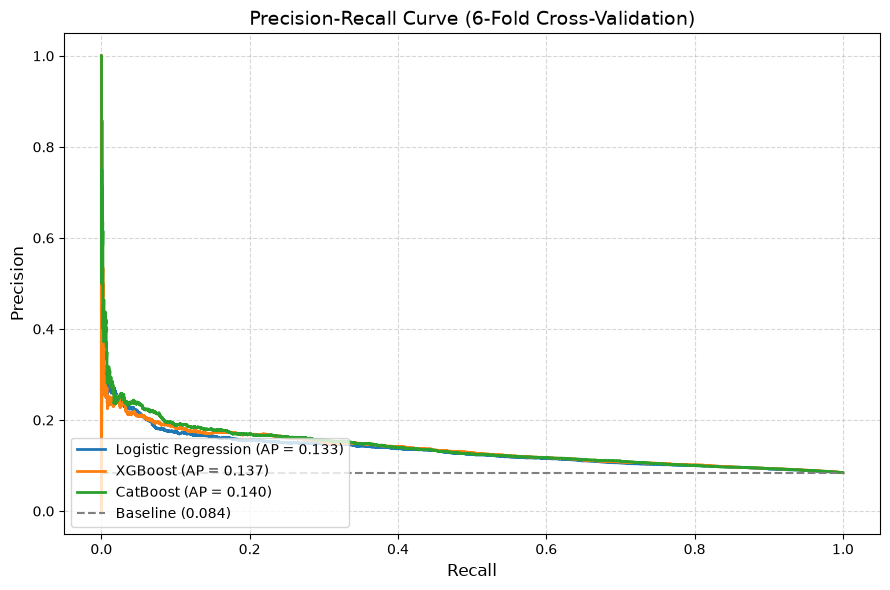

In [133]:
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# 1. Load các mô hình từ file .pkl
log_reg_pipeline = joblib.load("log_base_model.pkl")
xgboost_tunning_model = joblib.load("xgboost_tunning.pkl")
cat_tunning_model = joblib.load("cat_model.pkl")

cat_pipeline = Pipeline([
    ("catboost", cat_tunning_model)
])

# 2. Chuẩn hóa tập dữ liệu CatBoost
cat_cols = [
    'race', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'max_glu_serum', 'A1Cresult', 'level1_diag1'
]

# 3. Cấu hình danh sách mô hình
model_configs = [
    ("Logistic Regression", log_reg_pipeline, X_train, y_train),
    ("XGBoost", xgboost_tunning_model, X_train, y_train),
    ("CatBoost", cat_pipeline, X_train_cat, y_train_cat),
]

# 4. Khai báo StratifiedKFold
cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

plt.figure(figsize=(9, 6))

# 5. Chạy Cross-Validation và vẽ biểu đồ PR
for name, model, X, y in model_configs:
    y_probas = cross_val_predict(
        model, X, y, cv=cv, method="predict_proba"
    )
    y_scores = y_probas[:, 1]

    precision, recall, _ = precision_recall_curve(y, y_scores)
    ap_score = average_precision_score(y, y_scores)

    plt.plot(recall, precision, label=f"{name} (AP = {ap_score:.3f})", lw=2)

# 6. Vẽ đường Baseline
baseline = y_train.sum() / len(y_train)
plt.plot([0, 1], [baseline, baseline], linestyle="--", color="gray",
         label=f"Baseline ({baseline:.3f})")

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve (6-Fold Cross-Validation)", fontsize=14)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Chọn CatBoost để cải tiến

Kết hợp: 
- resample 70% chỉ dữ liệu train
- kết hợp với trọng số class weight của mô hình: class_weights={0: 1, 1: 5} - Class weights are used to assign different importance to different classes. By increasing the weight of the minority class, the model is penalized more for misclassifying minority class instances, thus improving its performance on the minority class.


In [135]:
from catboost import CatBoostClassifier

cat_cols = [
    'race', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'max_glu_serum', 'A1Cresult', 'level1_diag1'
]
cat_indices = [X_resampled.columns.get_loc(col) for col in cat_cols]

best_params = {
    'iterations': 500,
    'depth': 4,
    'learning_rate': 0.018489688756468402,
    'l2_leaf_reg': 0.0032362988111549118,
    'random_strength': 0.48580347723806133,
    'bagging_temperature': 0.8738560829870741,
    'class_weights': {0: 1, 1: 10},
    'random_seed': 42,
    'verbose': 0,
    'cat_features': cat_indices
}

cat_improve_model = CatBoostClassifier(**best_params)

In [137]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from catboost import CatBoostClassifier

kf = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)

precision_scores, recall_scores, f1_scores, roc_auc_scores, pr_auc_scores = [], [], [], [], []
thresholds = []

for train_idx, val_idx in kf.split(X_resampled, y_resampled):
    X_train_fold, X_val_fold = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_train_fold, y_val_fold = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    # Fit mô hình trên train fold
    model = CatBoostClassifier(**best_params)
    model.fit(X_train_fold, y_train_fold)

    # Tìm threshold tối ưu F1 trên train fold
    y_proba_train = model.predict_proba(X_train_fold)[:, 1]
    precisions, recalls, ths = precision_recall_curve(y_train_fold, y_proba_train)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_th = ths[np.argmax(f1s)]
    thresholds.append(best_th)

    # Đánh giá trên validation fold với threshold này
    y_proba_val = model.predict_proba(X_val_fold)[:, 1]
    y_pred_val = (y_proba_val >= best_th).astype(int)

    precision_scores.append(precision_score(y_val_fold, y_pred_val))
    recall_scores.append(recall_score(y_val_fold, y_pred_val))
    f1_scores.append(f1_score(y_val_fold, y_pred_val))
    roc_auc_scores.append(roc_auc_score(y_val_fold, y_proba_val))
    pr_auc_scores.append(average_precision_score(y_val_fold, y_proba_val))

print("Precision (mean):", np.mean(precision_scores))
print("Recall (mean):", np.mean(recall_scores))
print("F1-score (mean):", np.mean(f1_scores))
print("ROC-AUC (mean):", np.mean(roc_auc_scores))
print("PR-AUC (mean):", np.mean(pr_auc_scores))
print("Threshold trung bình:", np.mean(thresholds))

Precision (mean): 0.9538952086973311
Recall (mean): 0.8093435335646575
F1-score (mean): 0.8756825329622758
ROC-AUC (mean): 0.9337762156052659
PR-AUC (mean): 0.9412900557793238
Threshold trung bình: 0.8564852152742759


In [138]:
import joblib

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_resampled, y_resampled)
joblib.dump(final_model, 'catboost_final.pkl')

['catboost_final.pkl']

Đánh giá cuối trên test

In [139]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
# Dự đoán trên tập test
best_threshold = 0.8564852152742759

y_proba_test = final_model.predict_proba(X_test_cat_70)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

# Tính các chỉ số đánh giá
precision = precision_score(y_test_cat_70, y_pred_test)
recall = recall_score(y_test_cat_70, y_pred_test)
f1 = f1_score(y_test_cat_70, y_pred_test)
roc_auc = roc_auc_score(y_test_cat_70, y_proba_test)
pr_auc = average_precision_score(y_test_cat_70, y_proba_test)

# In kết quả
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Threshold: {best_threshold:.4f}")

# Thêm confusion matrix để trực quan hóa
cm = confusion_matrix(y_test_cat_70, y_pred_test)
print("Confusion Matrix:\n", cm)

Precision: 0.1586
Recall: 0.0513
F1-score: 0.0775
ROC-AUC: 0.5668
PR-AUC: 0.1081
Threshold: 0.8565
Confusion Matrix:
 [[10115   260]
 [  907    49]]
